**Roadmap**

In [1]:
# ============================================================
# Track B — Task 4 and Task 5
# 2D image data: index_images (40,20)
#
# Task 4A:
#   input  = index_images + period number n
#   output = S11(50) + S12(50)
#
# Task 4B:
#   input  = S11(50) + S12(50)
#   output = index_images(40,20) + recommended n
#
# Task 5A:
#   input  = index_images + period number n
#   output = S11(50) + scattering_loss_per_period_dB(50)
#
# Task 5B:
#   input  = specific S11 value + specific loss value at one wavelength
#   output = index_images(40,20) + recommended n
#
# We will:
#   1) inspect and clean the dataset
#   2) build strong forward predictors for 4A and 5A
#   3) build a baseline inverse model for 4B
#   4) build a conditional VAE for 5B
# ============================================================

**Imports**

In [2]:
import os
import math
import random
import warnings
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 130

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cuda


In [3]:
from google.colab import files
uploaded = files.upload()
H5_PATH = next(iter(uploaded.keys()))
print("Uploaded:", H5_PATH)

Saving phc_out_profile.h5 to phc_out_profile.h5
Uploaded: phc_out_profile.h5


**Quick structure check**

In [4]:
with h5py.File(H5_PATH, "r") as f:
    root_keys = list(f.keys())[:10]
    design_keys = sorted([k for k in f.keys() if k.startswith("design_")])
    wl = f["wavelengths_nm"][:]

    print("First root keys:", root_keys)
    print("Number of designs:", len(design_keys))
    print("Wavelength shape:", wl.shape)
    print("Wavelength head:", wl[:5])
    print("Wavelength tail:", wl[-5:])

    g = f[design_keys[0]]
    print("\nDatasets inside first design:")
    def walk(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"{name:35s} shape={obj.shape} dtype={obj.dtype}")
    g.visititems(walk)

First root keys: ['design_0000', 'design_0001', 'design_0002', 'design_0003', 'design_0004', 'design_0005', 'design_0006', 'design_0007', 'design_0008', 'design_0009']
Number of designs: 665
Wavelength shape: (50,)
Wavelength head: [1600.     1597.826  1595.6581 1593.496  1591.3396]
Wavelength tail: [1507.6923 1505.7618 1503.8363 1501.9156 1500.    ]

Datasets inside first design:
S_n_10/s11_power                    shape=(50,) dtype=float32
S_n_10/s12_power                    shape=(50,) dtype=float32
S_n_10/s21_power                    shape=(50,) dtype=float32
S_n_10/s22_power                    shape=(50,) dtype=float32
S_n_10/sim_time_s                   shape=() dtype=float64
S_n_10/simulation_error             shape=() dtype=float32
S_n_20/s11_power                    shape=(50,) dtype=float32
S_n_20/s12_power                    shape=(50,) dtype=float32
S_n_20/s21_power                    shape=(50,) dtype=float32
S_n_20/s22_power                    shape=(50,) dtype=float32
S_

**Load everything into memory**

In [5]:
def load_dataset(h5_path):
    rows = []
    with h5py.File(h5_path, "r") as f:
        wavelengths_nm = f["wavelengths_nm"][:].astype(np.float32)
        design_keys = sorted([k for k in f.keys() if k.startswith("design_")])

        for key in design_keys:
            g = f[key]

            row = {
                "design_key": key,
                "index_images": g["index_images"][:].astype(np.float32),             # (40,20)
                "image_matrices": g["image_matrices"][:].astype(np.float32),         # (2000,490)
                "y_width_arrays": g["y_width_arrays"][:].astype(np.float32),         # (100,)
                "inner_hole_arrays": g["inner_hole_arrays"][:].astype(np.float32),   # (32,2)

                "s11_n10": g["S_n_10/s11_power"][:].astype(np.float32),
                "s12_n10": g["S_n_10/s12_power"][:].astype(np.float32),
                "s21_n10": g["S_n_10/s21_power"][:].astype(np.float32),
                "s22_n10": g["S_n_10/s22_power"][:].astype(np.float32),

                "s11_n20": g["S_n_20/s11_power"][:].astype(np.float32),
                "s12_n20": g["S_n_20/s12_power"][:].astype(np.float32),
                "s21_n20": g["S_n_20/s21_power"][:].astype(np.float32),
                "s22_n20": g["S_n_20/s22_power"][:].astype(np.float32),

                "scattering_loss_per_period_dB": g["scattering_loss_per_period_dB"][:].astype(np.float32),
                "fwd_loss_per_period_dB": g["fwd_loss_per_period_dB"][:].astype(np.float32),
                "bwd_loss_per_period_dB": g["bwd_loss_per_period_dB"][:].astype(np.float32),
                "average_scattering_loss_dB": float(g["average_scattering_loss_dB"][()]),

                "err10": float(g["S_n_10/simulation_error"][()]),
                "err20": float(g["S_n_20/simulation_error"][()]),
                "time10": float(g["S_n_10/sim_time_s"][()]),
                "time20": float(g["S_n_20/sim_time_s"][()]),
            }
            rows.append(row)

    return wavelengths_nm, rows

wavelengths_nm, designs = load_dataset(H5_PATH)

print("Loaded designs:", len(designs))
print("Example image shape:", designs[0]["index_images"].shape)
print("Example S11 shape:", designs[0]["s11_n10"].shape)
print("Example loss shape:", designs[0]["scattering_loss_per_period_dB"].shape)

Loaded designs: 665
Example image shape: (40, 20)
Example S11 shape: (50,)
Example loss shape: (50,)


**First look at one sample**

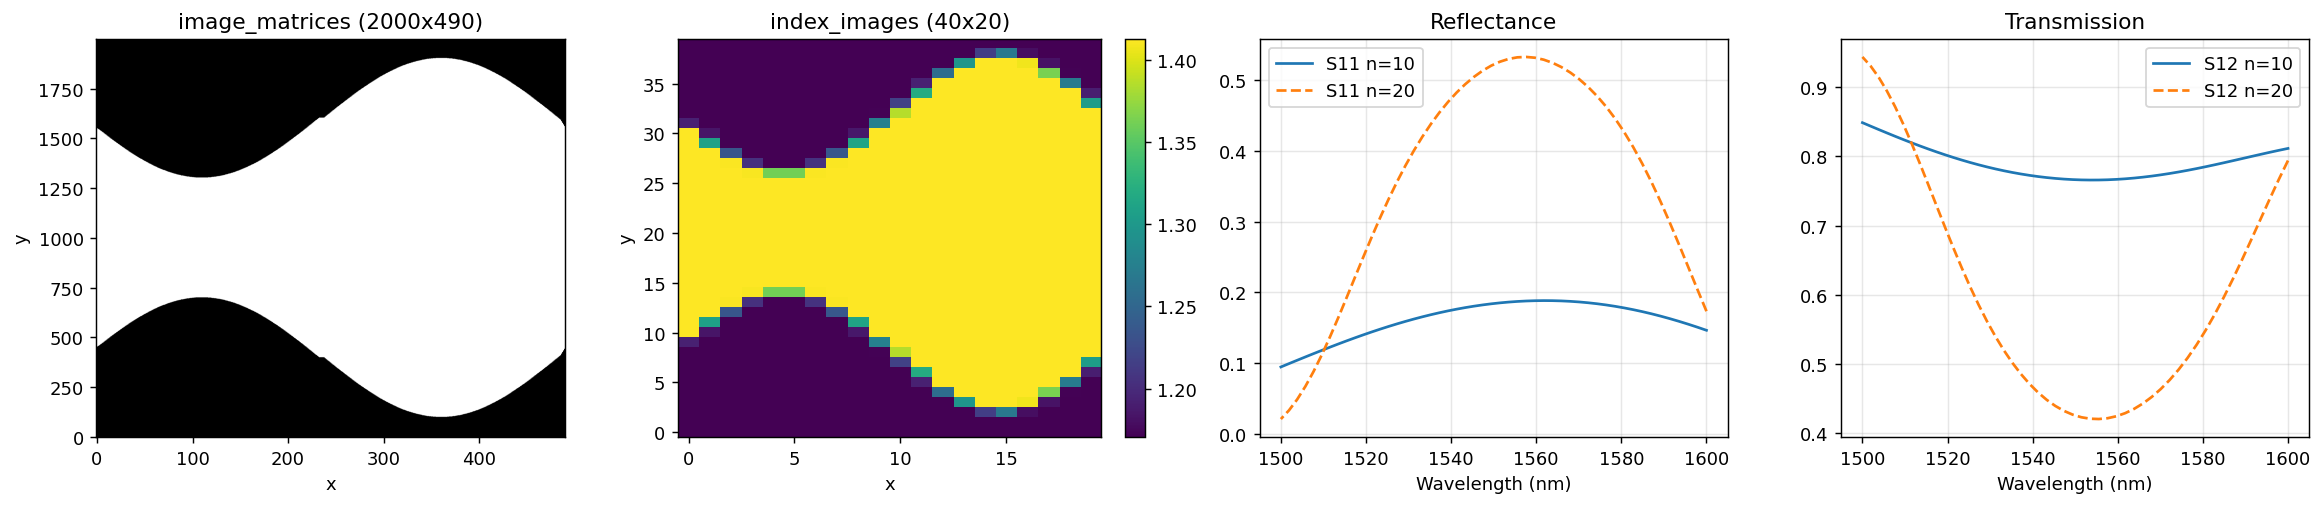

index_images min/max: 1.17047 1.4129113
valid loss wavelengths: 15 / 50
avg scattering loss: 0.0018857128452509642
simulation errors: 0.00552618270739913 0.005724657792598009


In [6]:
d = designs[9]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].imshow(d["image_matrices"], origin="lower", cmap="gray", aspect="auto")
axes[0].set_title("image_matrices (2000x490)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

im = axes[1].imshow(d["index_images"], origin="lower", aspect="auto")
axes[1].set_title("index_images (40x20)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].plot(wavelengths_nm, d["s11_n10"], label="S11 n=10")
axes[2].plot(wavelengths_nm, d["s11_n20"], label="S11 n=20", linestyle="--")
axes[2].set_title("Reflectance")
axes[2].set_xlabel("Wavelength (nm)")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

axes[3].plot(wavelengths_nm, d["s12_n10"], label="S12 n=10")
axes[3].plot(wavelengths_nm, d["s12_n20"], label="S12 n=20", linestyle="--")
axes[3].set_title("Transmission")
axes[3].set_xlabel("Wavelength (nm)")
axes[3].grid(True, alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

print("index_images min/max:", d["index_images"].min(), d["index_images"].max())
print("valid loss wavelengths:", np.isfinite(d["scattering_loss_per_period_dB"]).sum(), "/", len(wavelengths_nm))
print("avg scattering loss:", d["average_scattering_loss_dB"])
print("simulation errors:", d["err10"], d["err20"])

**Dataset summary table**

In [7]:
summary_rows = []

for d in designs:
    summary_rows.append({
        "design_key": d["design_key"],
        "img_min": float(np.min(d["index_images"])),
        "img_max": float(np.max(d["index_images"])),
        "s11max10": float(np.max(d["s11_n10"])),
        "s11max20": float(np.max(d["s11_n20"])),
        "s12min10": float(np.min(d["s12_n10"])),
        "s12min20": float(np.min(d["s12_n20"])),
        "loss_valid": int(np.isfinite(d["scattering_loss_per_period_dB"]).sum()),
        "avg_loss": d["average_scattering_loss_dB"],
        "err10": d["err10"],
        "err20": d["err20"],
        "time10": d["time10"],
        "time20": d["time20"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.head()

,design_key,img_min,img_max,s11max10,s11max20,s12min10,s12min20,loss_valid,avg_loss,err10,err20,time10,time20
0,design_0000,1.17047,1.412911,0.281750,0.670580,0.668193,0.292308,0,NaN,0.002734,0.001925,66.571927,96.145278
1,design_0001,1.17047,1.412911,0.341245,0.745919,0.610078,0.213959,0,NaN,0.005598,0.003570,59.507606,95.757482
2,design_0002,1.17047,1.412911,0.378715,0.780433,0.567519,0.173488,0,NaN,0.006584,0.003570,59.801921,98.930521
3,design_0003,1.17047,1.412911,0.426482,0.814623,0.533676,0.145453,23,0.001281,0.006523,0.003032,62.499836,100.767950
4,design_0004,1.17047,1.412911,0.445532,0.821308,0.507083,0.128495,28,0.003599,0.005434,0.002502,61.575207,104.402812


**EDA plots**

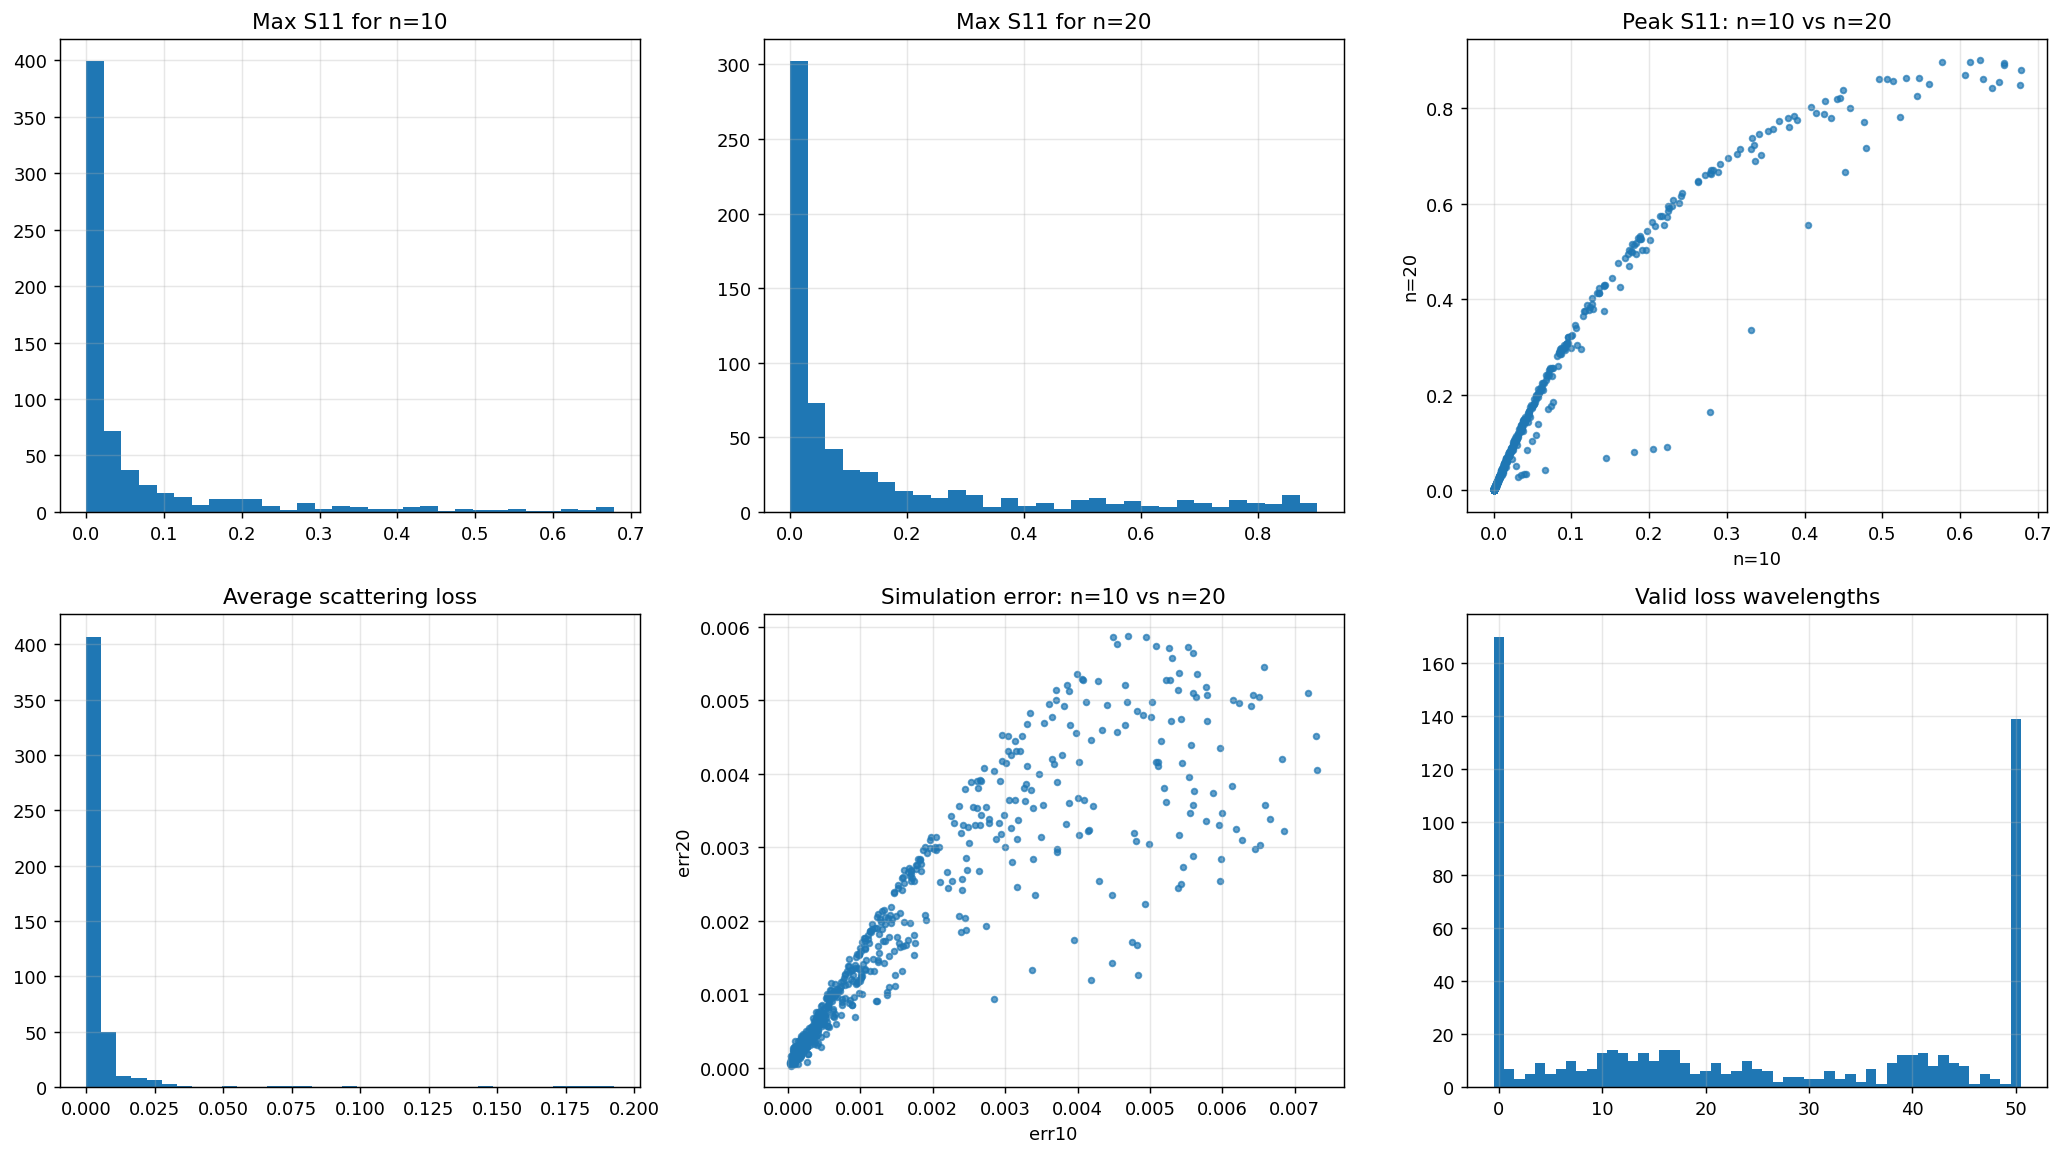

            count       mean        std        min        25%        50%  \
img_min     665.0   1.170470   0.000000   1.170470   1.170470   1.170470   
img_max     665.0   1.412911   0.000000   1.412911   1.412911   1.412911   
s11max10    665.0   0.068647   0.130450   0.000028   0.001569   0.010807   
s11max20    665.0   0.158224   0.236805   0.000050   0.005828   0.038882   
s12min10    665.0   0.888223   0.150305   0.186196   0.887950   0.948464   
s12min20    665.0   0.798663   0.253151   0.013257   0.742073   0.920358   
loss_valid  665.0  22.858647  19.720667   0.000000   0.000000  18.000000   
avg_loss    495.0   0.005687   0.019389   0.000004   0.000487   0.001441   
err10       665.0   0.001640   0.001828   0.000028   0.000237   0.000846   
err20       665.0   0.001714   0.001603   0.000026   0.000342   0.001110   
time10      665.0  55.989108   2.643591  50.626820  53.763917  55.581184   
time20      665.0  86.188382   7.900665  70.835055  81.101621  84.602149   

           

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].hist(summary_df["s11max10"], bins=30)
axes[0,0].set_title("Max S11 for n=10")
axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(summary_df["s11max20"], bins=30)
axes[0,1].set_title("Max S11 for n=20")
axes[0,1].grid(True, alpha=0.3)

axes[0,2].scatter(summary_df["s11max10"], summary_df["s11max20"], s=10, alpha=0.7)
axes[0,2].set_title("Peak S11: n=10 vs n=20")
axes[0,2].set_xlabel("n=10")
axes[0,2].set_ylabel("n=20")
axes[0,2].grid(True, alpha=0.3)

axes[1,0].hist(summary_df["avg_loss"].dropna(), bins=35)
axes[1,0].set_title("Average scattering loss")
axes[1,0].grid(True, alpha=0.3)

axes[1,1].scatter(summary_df["err10"], summary_df["err20"], s=10, alpha=0.7)
axes[1,1].set_title("Simulation error: n=10 vs n=20")
axes[1,1].set_xlabel("err10")
axes[1,1].set_ylabel("err20")
axes[1,1].grid(True, alpha=0.3)

axes[1,2].hist(summary_df["loss_valid"], bins=np.arange(-0.5, 51.5, 1))
axes[1,2].set_title("Valid loss wavelengths")
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(summary_df.describe().T)

**Random montage of index_images**

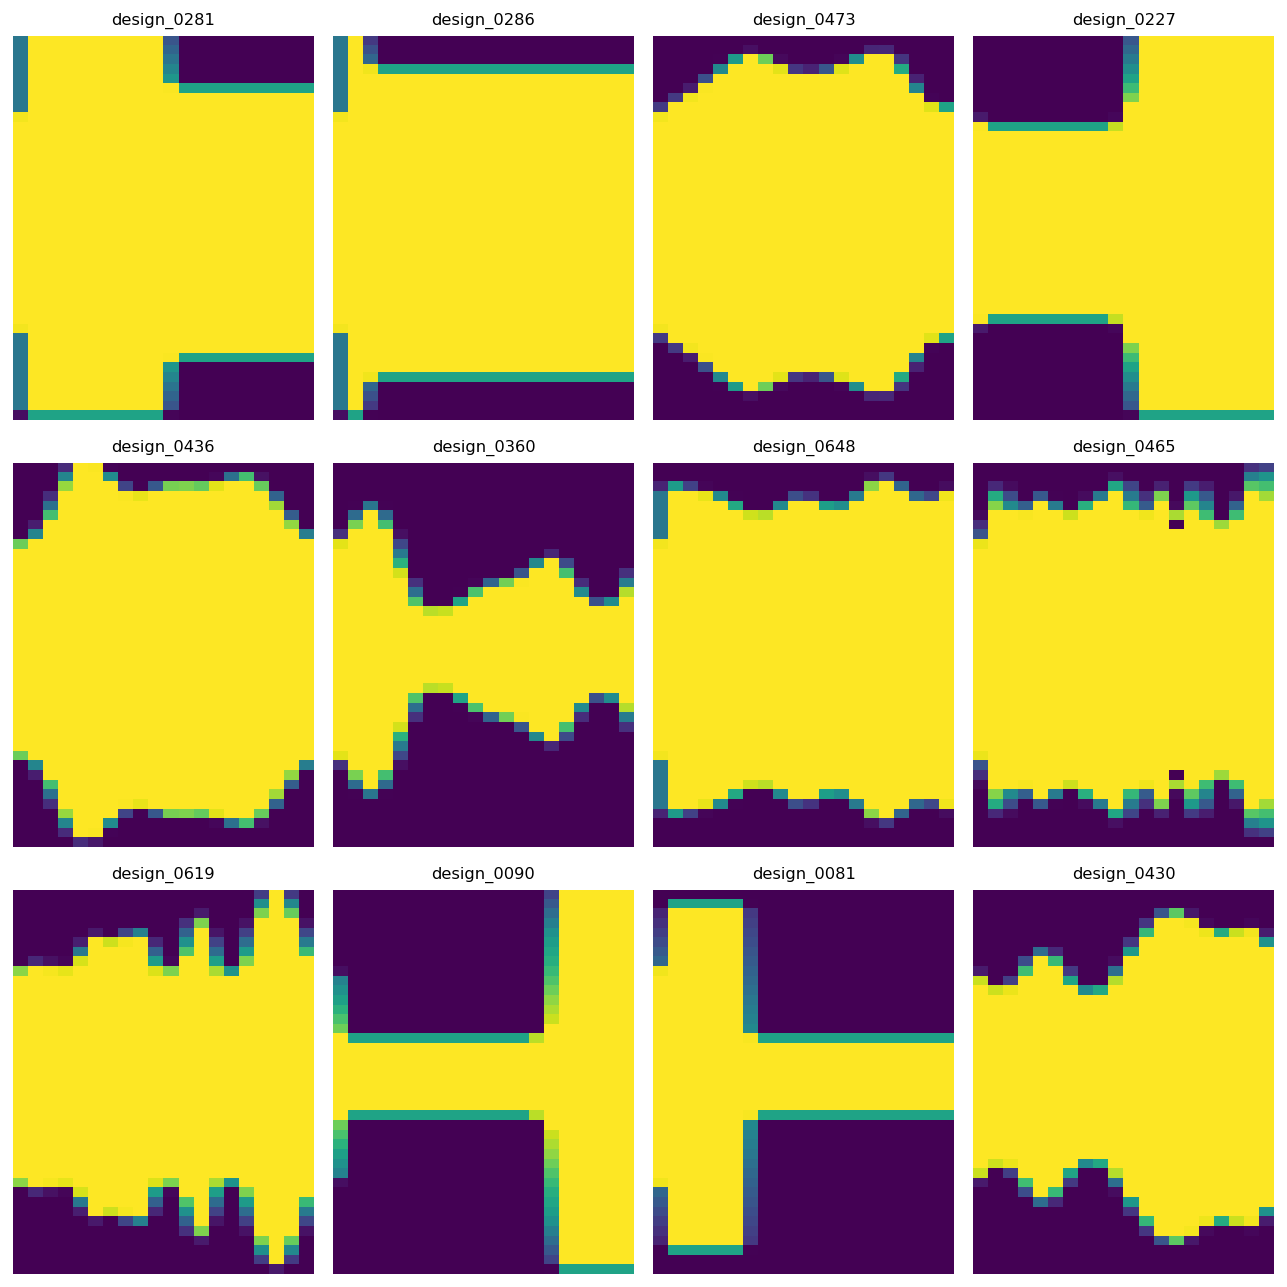

In [9]:
n_show = 12
idxs = np.random.choice(len(designs), size=n_show, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(10, 10))
for ax, idx in zip(axes.ravel(), idxs):
    ax.imshow(designs[idx]["index_images"], origin="lower", aspect="auto")
    ax.set_title(designs[idx]["design_key"], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

If we randomly split samples without grouping by design,the exact same geometry can leak into train and test and that would fake a good score.

**Build sample lists for Task 4A and 5A**

In [10]:
def normalize_image(img):
    img = img.astype(np.float32)
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-8)

task4_samples = []
task5_samples = []

for d in designs:
    img = normalize_image(d["index_images"])

    for n in [10, 20]:
        s11 = d[f"s11_n{n}"]
        s12 = d[f"s12_n{n}"]

        task4_samples.append({
            "design_key": d["design_key"],
            "image": img,
            "n": float(n),
            "s11": s11.astype(np.float32),
            "s12": s12.astype(np.float32),
            "sim_error": d["err10"] if n == 10 else d["err20"],
        })

        task5_samples.append({
            "design_key": d["design_key"],
            "image": img,
            "n": float(n),
            "s11": s11.astype(np.float32),
            "loss": d["scattering_loss_per_period_dB"].astype(np.float32),
            "sim_error": d["err10"] if n == 10 else d["err20"],
        })

print("Task 4 sample count:", len(task4_samples))
print("Task 5 sample count:", len(task5_samples))

Task 4 sample count: 1330
Task 5 sample count: 1330


**Split by design key**

In [11]:
all_design_keys = sorted(set(x["design_key"] for x in task4_samples))

train_keys, temp_keys = train_test_split(all_design_keys, test_size=0.30, random_state=SEED)
val_keys, test_keys   = train_test_split(temp_keys, test_size=0.50, random_state=SEED)

train_keys = set(train_keys)
val_keys   = set(val_keys)
test_keys  = set(test_keys)

def split_samples(samples):
    train = [x for x in samples if x["design_key"] in train_keys]
    val   = [x for x in samples if x["design_key"] in val_keys]
    test  = [x for x in samples if x["design_key"] in test_keys]
    return train, val, test

task4_train, task4_val, task4_test = split_samples(task4_samples)
task5_train, task5_val, task5_test = split_samples(task5_samples)

print("Task 4 split:", len(task4_train), len(task4_val), len(task4_test))
print("Task 5 split:", len(task5_train), len(task5_val), len(task5_test))

Task 4 split: 930 200 200
Task 5 split: 930 200 200


**Dataset classes**

In [12]:
class Task4Dataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        x_img = torch.tensor(s["image"][None, :, :], dtype=torch.float32)  # (1,40,20)
        x_n   = torch.tensor([(s["n"] - 10.0) / 10.0], dtype=torch.float32)
        y     = torch.tensor(np.concatenate([s["s11"], s["s12"]]), dtype=torch.float32)  # (100,)
        w     = torch.tensor(1.0 / (1e-4 + s["sim_error"]), dtype=torch.float32)
        return x_img, x_n, y, w


class Task5Dataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        x_img = torch.tensor(s["image"][None, :, :], dtype=torch.float32)
        x_n   = torch.tensor([(s["n"] - 10.0) / 10.0], dtype=torch.float32)

        y_s11 = torch.tensor(s["s11"], dtype=torch.float32)

        loss = s["loss"].copy()
        mask = np.isfinite(loss).astype(np.float32)
        avg_loss = np.nanmean(loss) if np.isfinite(loss).sum() > 0 else 0.0
        loss = np.nan_to_num(loss, nan=0.0)

        y_loss = torch.tensor(loss, dtype=torch.float32)
        y_mask = torch.tensor(mask, dtype=torch.float32)
        y_avg_loss = torch.tensor([avg_loss], dtype=torch.float32)

        w = torch.tensor(1.0 / (1e-4 + s["sim_error"]), dtype=torch.float32)

        return x_img, x_n, y_s11, y_loss, y_mask, y_avg_loss, w



BATCH_SIZE = 32

task4_train_dl = DataLoader(Task4Dataset(task4_train), batch_size=BATCH_SIZE, shuffle=True)
task4_val_dl   = DataLoader(Task4Dataset(task4_val),   batch_size=BATCH_SIZE, shuffle=False)
task4_test_dl  = DataLoader(Task4Dataset(task4_test),  batch_size=BATCH_SIZE, shuffle=False)

task5_train_dl = DataLoader(Task5Dataset(task5_train), batch_size=BATCH_SIZE, shuffle=True)
task5_val_dl   = DataLoader(Task5Dataset(task5_val),   batch_size=BATCH_SIZE, shuffle=False)
task5_test_dl  = DataLoader(Task5Dataset(task5_test),  batch_size=BATCH_SIZE, shuffle=False)

**Forward model architecture**

In [67]:
class ImageEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 40x20 -> 20x10

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 20x10 -> 10x5

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 10x5 -> 5x2

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 5 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.fc(self.net(x))


class ScalarEncoder(nn.Module):
    def __init__(self, out_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, out_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class Task4Predictor(nn.Module):
    """
    Physics-aware version:
    - predicts S11 directly
    - predicts a nonnegative residual term L_res via softplus
    - computes S12 = 1 - S11 - L_res
    This automatically encourages:
        S11 + S12 <= 1
        S12 to go down when S11 goes up
    """
    def __init__(self):
        super().__init__()
        self.img_enc = ImageEncoder(128)
        self.n_enc   = ScalarEncoder(16)
        self.shared  = nn.Sequential(
            nn.Linear(128 + 16, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.s11_head = nn.Linear(128, 50)
        self.residual_head = nn.Linear(128, 50)

    def forward(self, x_img, x_n):
        z = torch.cat([self.img_enc(x_img), self.n_enc(x_n)], dim=1)
        h = self.shared(z)

        # Bound S11 to [0,1]
        s11 = torch.sigmoid(self.s11_head(h))

        # Nonnegative leftover term so S11 + S12 <= 1
        residual = F.softplus(self.residual_head(h))

        s12 = 1.0 - s11 - residual
        s12 = torch.clamp(s12, min=0.0, max=1.0)

        out = torch.cat([s11, s12], dim=1)
        return out


class Task5Predictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.img_enc = ImageEncoder(128)
        self.n_enc   = ScalarEncoder(16)
        self.shared  = nn.Sequential(
            nn.Linear(128 + 16, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.s11_head  = nn.Linear(128, 50)
        self.loss_head = nn.Linear(128, 50)
        self.avg_loss_head = nn.Linear(128, 1)   # fallback easier target

    def forward(self, x_img, x_n):
        z = torch.cat([self.img_enc(x_img), self.n_enc(x_n)], dim=1)
        h = self.shared(z)

        s11 = torch.sigmoid(self.s11_head(h))
        loss = self.loss_head(h)
        avg_loss = self.avg_loss_head(h)

        return s11, loss, avg_loss

**Losses and helpers**

In [68]:
def weighted_mse(pred, target, sample_weight):
    err = (pred - target) ** 2
    err = err.mean(dim=1)
    err = err * sample_weight
    return err.mean()


def masked_weighted_mse(pred, target, mask, sample_weight):
    err = (pred - target) ** 2
    err = err * mask
    err = err.sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
    err = err * sample_weight
    return err.mean()


def smoothness_loss(curve):
    """
    Penalize rough / jagged spectra.
    Uses second finite difference.
    """
    d2 = curve[:, 2:] - 2 * curve[:, 1:-1] + curve[:, :-2]
    return (d2 ** 2).mean()


def energy_violation_loss(s11, s12):
    """
    Penalize S11 + S12 > 1.
    """
    excess = torch.relu(s11 + s12 - 1.0)
    return (excess ** 2).mean()


def opposite_trend_loss(s11, s12):
    """
    Encourage opposite local trends:
    if S11 slope > 0, S12 slope should tend < 0, and vice versa.
    """
    ds11 = s11[:, 1:] - s11[:, :-1]
    ds12 = s12[:, 1:] - s12[:, :-1]
    return torch.mean((ds11 + ds12) ** 2)

**Train Task 4A**

In [69]:
def run_epoch_task4(model, loader, optimizer=None,
                    lambda_smooth=0.05,
                    lambda_energy=1.0,
                    lambda_opposite=0.2):
    train_mode = optimizer is not None
    model.train(train_mode)

    total_loss = 0.0
    total_n = 0

    for x_img, x_n, y, w in loader:
        x_img, x_n, y, w = x_img.to(DEVICE), x_n.to(DEVICE), y.to(DEVICE), w.to(DEVICE)

        pred = model(x_img, x_n)
        pred_s11, pred_s12 = pred[:, :50], pred[:, 50:]

        fit_loss = weighted_mse(pred, y, w)
        smooth_loss = smoothness_loss(pred_s11) + smoothness_loss(pred_s12)
        phys_loss = energy_violation_loss(pred_s11, pred_s12)
        trend_loss = opposite_trend_loss(pred_s11, pred_s12)

        loss = fit_loss + lambda_smooth * smooth_loss + lambda_energy * phys_loss + lambda_opposite * trend_loss

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = x_img.size(0)
        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / total_n


task4_model = Task4Predictor().to(DEVICE)
opt4 = torch.optim.Adam(task4_model.parameters(), lr=8e-4, weight_decay=1e-5)

history4 = {"train": [], "val": []}
best_val4 = np.inf
best_state4 = None

EPOCHS = 300

for epoch in range(EPOCHS):
    tr = run_epoch_task4(task4_model, task4_train_dl, optimizer=opt4)
    va = run_epoch_task4(task4_model, task4_val_dl, optimizer=None)

    history4["train"].append(tr)
    history4["val"].append(va)

    if va < best_val4:
        best_val4 = va
        best_state4 = {k: v.cpu().clone() for k, v in task4_model.state_dict().items()}

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d} | train={tr:.6f} | val={va:.6f}")

task4_model.load_state_dict(best_state4)
print("Best val loss:", best_val4)

Epoch 001 | train=453.896558 | val=145.820098
Epoch 010 | train=4.092641 | val=3.648254
Epoch 020 | train=1.697455 | val=1.933433
Epoch 030 | train=1.162906 | val=1.681570
Epoch 040 | train=0.671088 | val=0.892603
Epoch 050 | train=0.508583 | val=0.909160
Epoch 060 | train=0.665537 | val=0.907628
Epoch 070 | train=0.593309 | val=0.697889
Epoch 080 | train=0.361274 | val=0.676062
Epoch 090 | train=0.430975 | val=0.700111
Epoch 100 | train=0.419518 | val=0.691985
Epoch 110 | train=0.243562 | val=0.559679
Epoch 120 | train=0.228309 | val=0.391882
Epoch 130 | train=0.230561 | val=0.411737
Epoch 140 | train=0.204632 | val=0.369842
Epoch 150 | train=0.238922 | val=0.462429
Epoch 160 | train=0.169183 | val=0.434696
Epoch 170 | train=0.195319 | val=0.413788
Epoch 180 | train=0.158612 | val=0.457791
Epoch 190 | train=0.436718 | val=0.751454
Epoch 200 | train=0.680450 | val=0.746257
Epoch 210 | train=0.279949 | val=0.428643
Epoch 220 | train=0.169328 | val=0.359910
Epoch 230 | train=0.147999 | v

**Plot Task 4A learning curve**

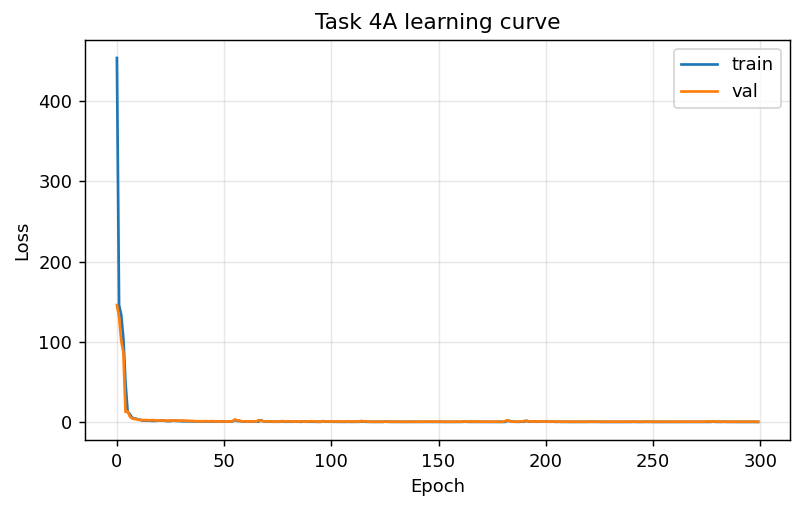

In [70]:
plt.figure(figsize=(7, 4))
plt.plot(history4["train"], label="train")
plt.plot(history4["val"], label="val")
plt.title("Task 4A learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Evaluate Task 4A**

Task 4A mean MAE: 0.015027984
Task 4A S11 MAE: 0.014508967
Task 4A S12 MAE: 0.015547006


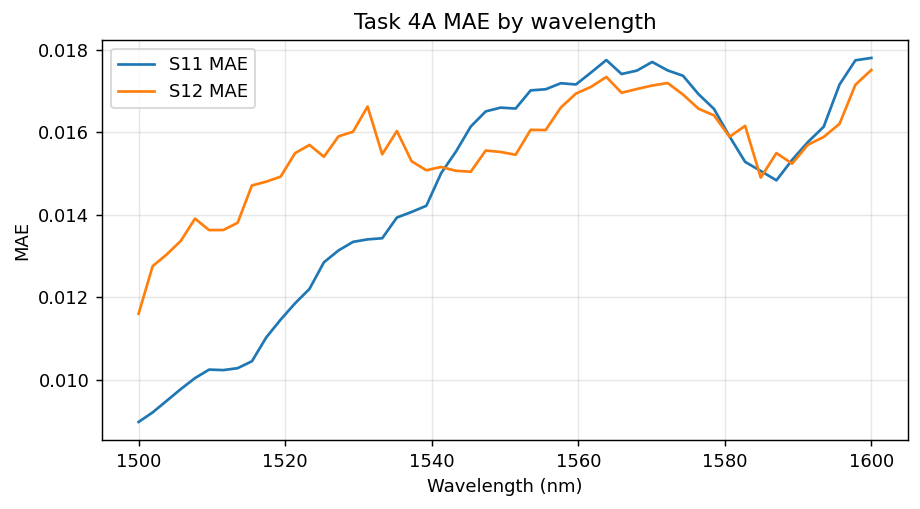

In [71]:
def collect_task4(model, loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for x_img, x_n, y, w in loader:
            pred = model(x_img.to(DEVICE), x_n.to(DEVICE)).cpu().numpy()
            preds.append(pred)
            trues.append(y.numpy())

    preds = np.concatenate(preds, axis=0)
    trues = np.concatenate(trues, axis=0)
    return preds, trues

pred4, true4 = collect_task4(task4_model, task4_test_dl)

mae4 = np.mean(np.abs(pred4 - true4), axis=0)
mae4_s11 = mae4[:50]
mae4_s12 = mae4[50:]

print("Task 4A mean MAE:", mae4.mean())
print("Task 4A S11 MAE:", mae4_s11.mean())
print("Task 4A S12 MAE:", mae4_s12.mean())

plt.figure(figsize=(8, 4))
plt.plot(wavelengths_nm, mae4_s11, label="S11 MAE")
plt.plot(wavelengths_nm, mae4_s12, label="S12 MAE")
plt.title("Task 4A MAE by wavelength")
plt.xlabel("Wavelength (nm)")
plt.ylabel("MAE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



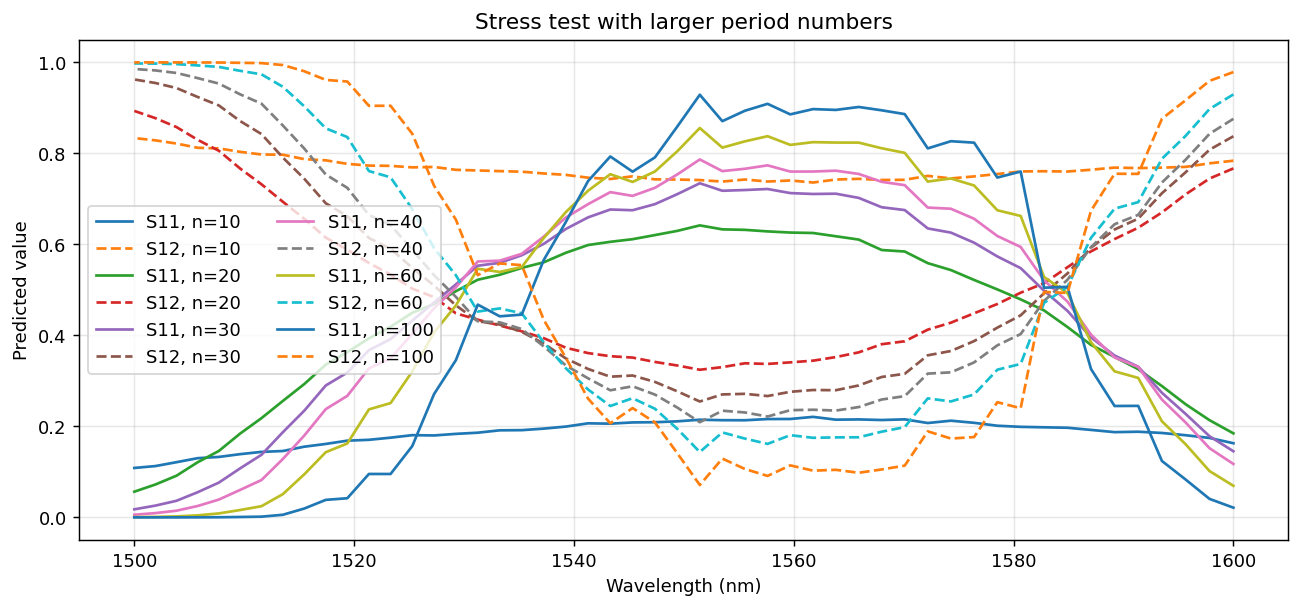

In [72]:
# Stress test: feed larger period numbers than seen in training
#check whether S11 / S12 explode for large N

task4_model.eval()

sample_img = torch.tensor(task4_test[0]["image"][None, None, :, :], dtype=torch.float32).to(DEVICE)

test_ns = [10, 20, 30, 40, 60, 100]
plt.figure(figsize=(12, 5))

for n in test_ns:
    x_n = torch.tensor([[(n - 10.0) / 10.0]], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        pred = task4_model(sample_img, x_n).cpu().numpy()[0]
    pred_s11 = pred[:50]
    pred_s12 = pred[50:]

    plt.plot(wavelengths_nm, pred_s11, label=f"S11, n={n}")
    plt.plot(wavelengths_nm, pred_s12, linestyle="--", label=f"S12, n={n}")

plt.title("Stress test with larger period numbers")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Predicted value")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.show()

**Show Task 4A predictions**

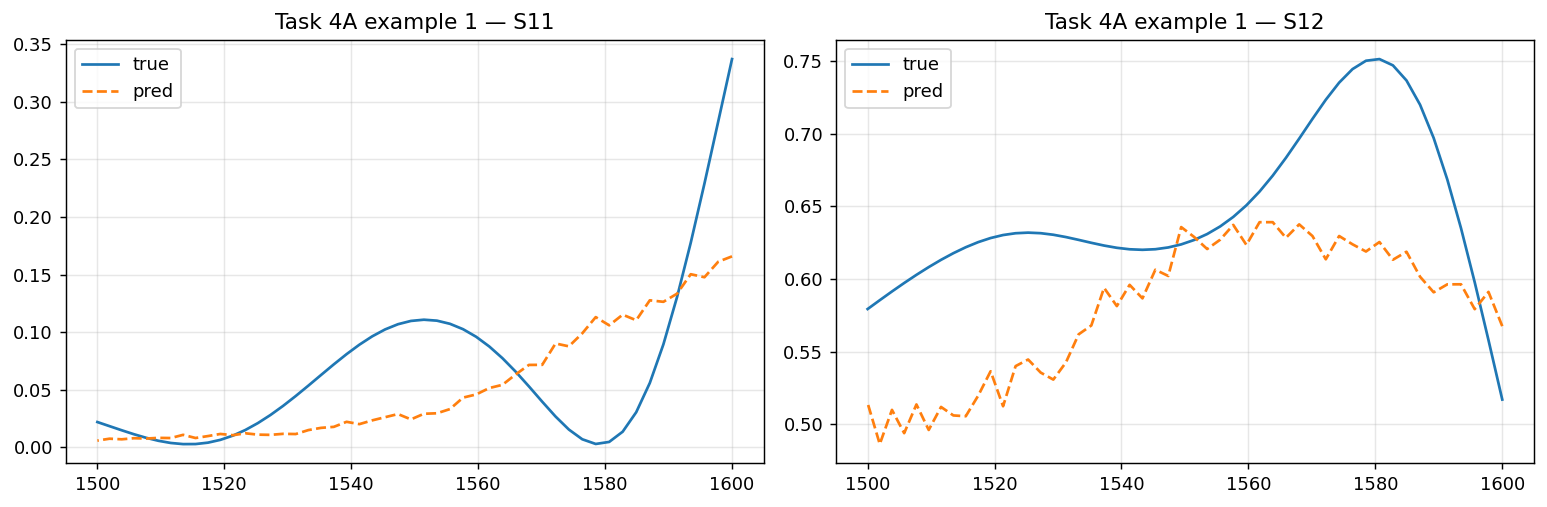

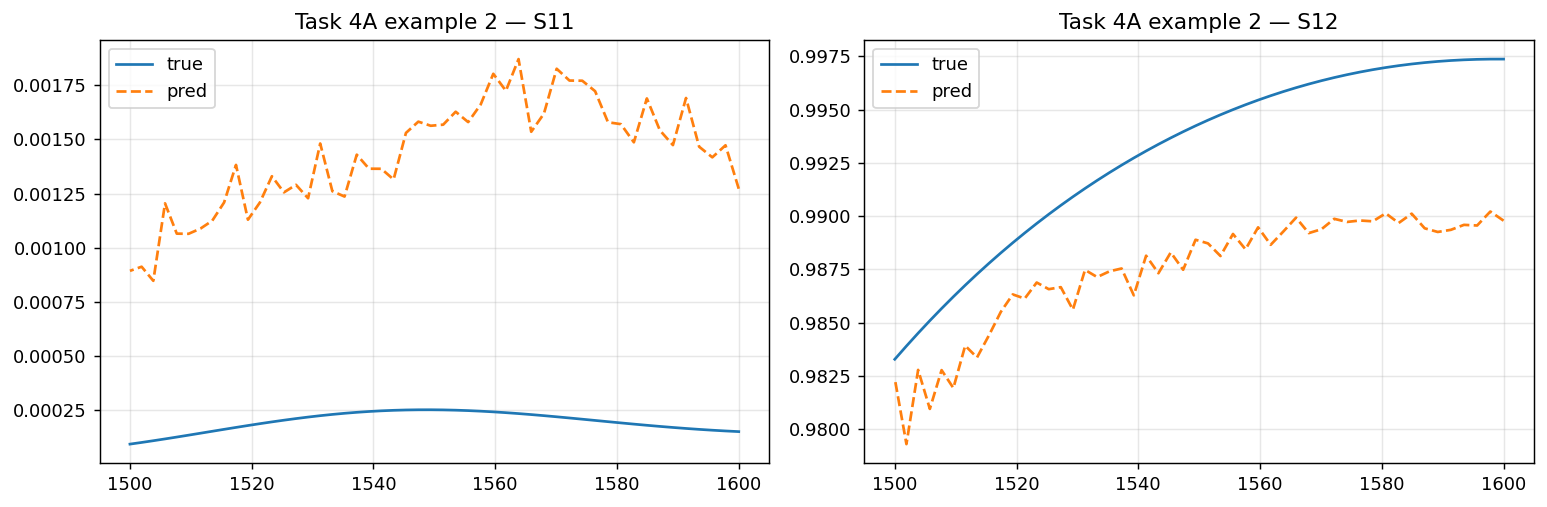

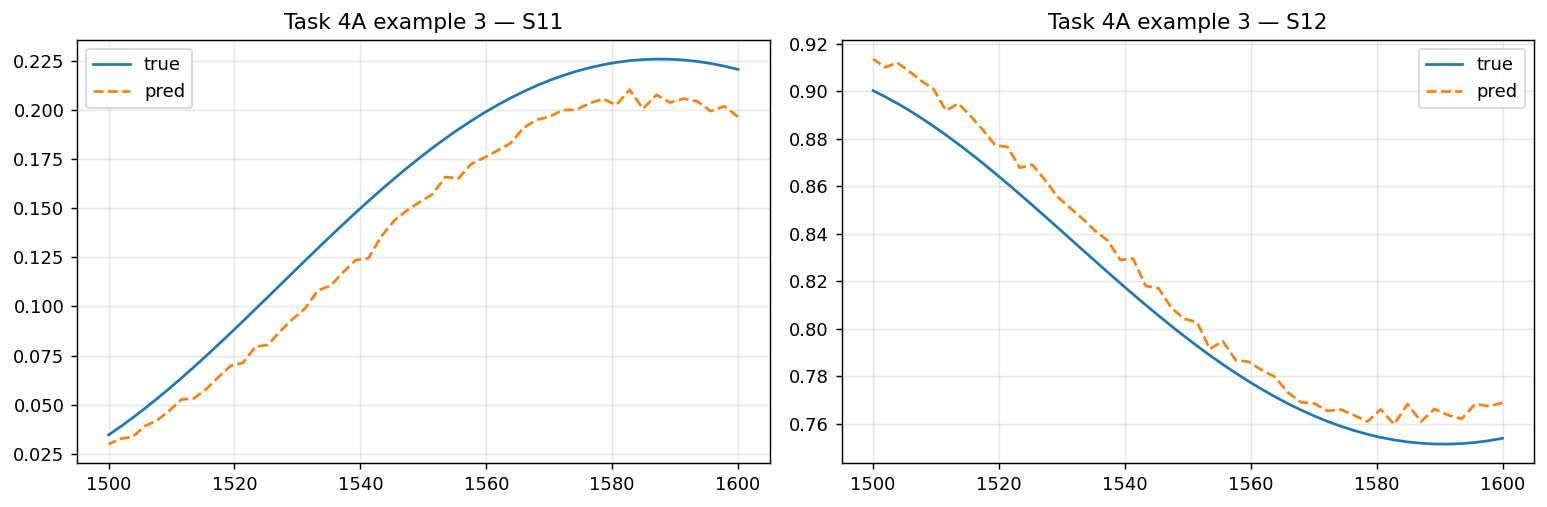

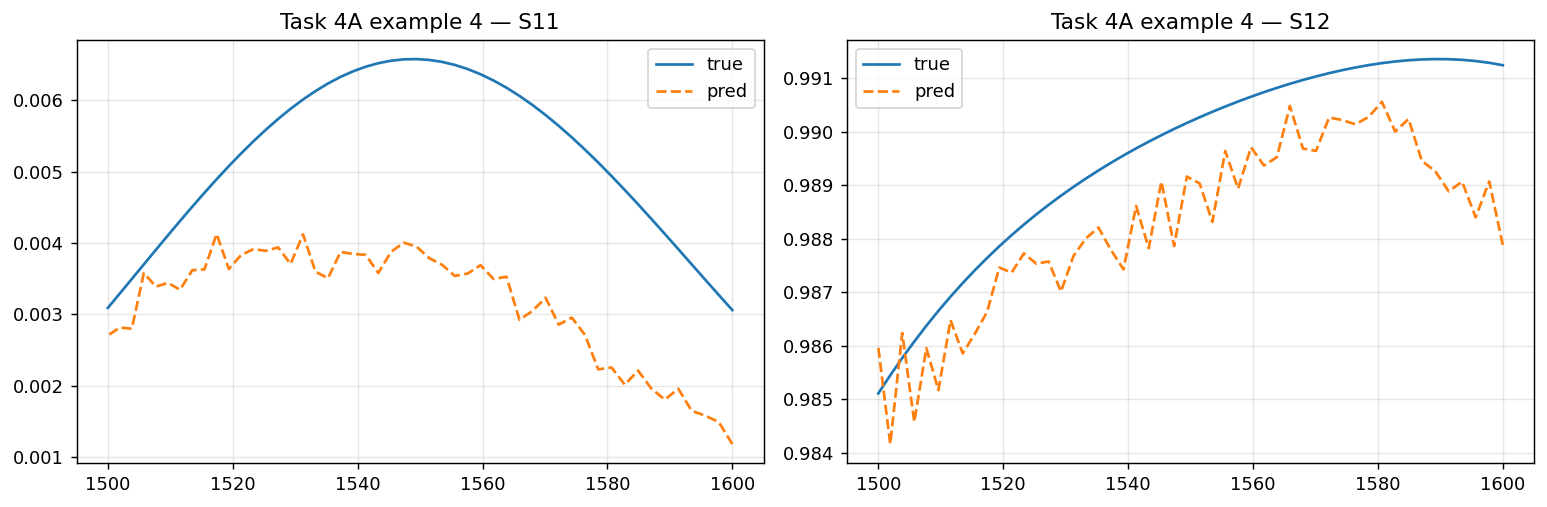

In [73]:
idxs = np.random.choice(len(pred4), size=4, replace=False)

for k, i in enumerate(idxs, start=1):
    t_s11 = true4[i, :50]
    t_s12 = true4[i, 50:]
    p_s11 = pred4[i, :50]
    p_s12 = pred4[i, 50:]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(wavelengths_nm, t_s11, label="true")
    axes[0].plot(wavelengths_nm, p_s11, label="pred", linestyle="--")
    axes[0].set_title(f"Task 4A example {k} — S11")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(wavelengths_nm, t_s12, label="true")
    axes[1].plot(wavelengths_nm, p_s12, label="pred", linestyle="--")
    axes[1].set_title(f"Task 4A example {k} — S12")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

**Train Task 5A**

In [94]:
def run_epoch_task5(model, loader, optimizer=None,
                    alpha=1.0,
                    beta=0.1,
                    gamma=1.0,
                    lambda_smooth=0.05):
    train_mode = optimizer is not None
    model.train(train_mode)

    total = 0.0
    total_s11 = 0.0
    total_lossspec = 0.0
    total_avgloss = 0.0
    total_n = 0

    for x_img, x_n, y_s11, y_loss, y_mask, y_avg_loss, w in loader:
        x_img = x_img.to(DEVICE)
        x_n   = x_n.to(DEVICE)
        y_s11 = y_s11.to(DEVICE)
        y_loss = y_loss.to(DEVICE)
        y_mask = y_mask.to(DEVICE)
        y_avg_loss = y_avg_loss.to(DEVICE)
        w = w.to(DEVICE)

        p_s11, p_loss, p_avg_loss = model(x_img, x_n)

        loss_s11 = weighted_mse(p_s11, y_s11, w) + lambda_smooth * smoothness_loss(p_s11)
        loss_lossspec = masked_weighted_mse(p_loss, y_loss, y_mask, w)
        loss_avgloss = weighted_mse(p_avg_loss, y_avg_loss, w)

        loss = alpha * loss_s11 + beta * loss_lossspec + gamma * loss_avgloss

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = x_img.size(0)
        total += loss.item() * bs
        total_s11 += loss_s11.item() * bs
        total_lossspec += loss_lossspec.item() * bs
        total_avgloss += loss_avgloss.item() * bs
        total_n += bs

    return (
        total / total_n,
        total_s11 / total_n,
        total_lossspec / total_n,
        total_avgloss / total_n,
    )


task5_model = Task5Predictor().to(DEVICE)
opt5 = torch.optim.Adam(task5_model.parameters(), lr=8e-4, weight_decay=1e-5)

history5 = {
    "train_total": [], "val_total": [],
    "train_s11": [], "val_s11": [],
    "train_lossspec": [], "val_lossspec": [],
    "train_avgloss": [], "val_avgloss": []
}

best_val5 = np.inf
best_state5 = None

EPOCHS = 300

for epoch in range(EPOCHS):
    tr_total, tr_s11, tr_lossspec, tr_avgloss = run_epoch_task5(task5_model, task5_train_dl, optimizer=opt5)
    va_total, va_s11, va_lossspec, va_avgloss = run_epoch_task5(task5_model, task5_val_dl, optimizer=None)

    history5["train_total"].append(tr_total)
    history5["val_total"].append(va_total)
    history5["train_s11"].append(tr_s11)
    history5["val_s11"].append(va_s11)
    history5["train_lossspec"].append(tr_lossspec)
    history5["val_lossspec"].append(va_lossspec)
    history5["train_avgloss"].append(tr_avgloss)
    history5["val_avgloss"].append(va_avgloss)

    if va_total < best_val5:
        best_val5 = va_total
        best_state5 = {k: v.cpu().clone() for k, v in task5_model.state_dict().items()}

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch+1:03d} | "
            f"train={tr_total:.6f} | val={va_total:.6f} | "
            f"val_s11={va_s11:.6f} | val_lossspec={va_lossspec:.6f} | val_avgloss={va_avgloss:.6f}"
        )

task5_model.load_state_dict(best_state5)
print("Best val total loss:", best_val5)

Epoch 001 | train=181.162411 | val=22.264070 | val_s11=15.240032 | val_lossspec=17.627617 | val_avgloss=5.261276
Epoch 010 | train=2.315279 | val=2.246414 | val_s11=1.739250 | val_lossspec=1.363874 | val_avgloss=0.370777
Epoch 020 | train=1.133868 | val=2.280452 | val_s11=2.134442 | val_lossspec=0.514681 | val_avgloss=0.094542
Epoch 030 | train=0.754257 | val=1.042775 | val_s11=0.820959 | val_lossspec=0.390630 | val_avgloss=0.182753
Epoch 040 | train=0.524326 | val=0.792822 | val_s11=0.635873 | val_lossspec=0.288644 | val_avgloss=0.128085
Epoch 050 | train=0.547480 | val=0.615106 | val_s11=0.577115 | val_lossspec=0.205243 | val_avgloss=0.017467
Epoch 060 | train=0.783270 | val=1.405159 | val_s11=1.344902 | val_lossspec=0.212396 | val_avgloss=0.039017
Epoch 070 | train=0.321023 | val=0.566355 | val_s11=0.499935 | val_lossspec=0.145979 | val_avgloss=0.051822
Epoch 080 | train=0.244915 | val=0.378456 | val_s11=0.352264 | val_lossspec=0.122899 | val_avgloss=0.013903
Epoch 090 | train=0.440

**Plot Task 5A learning curves**

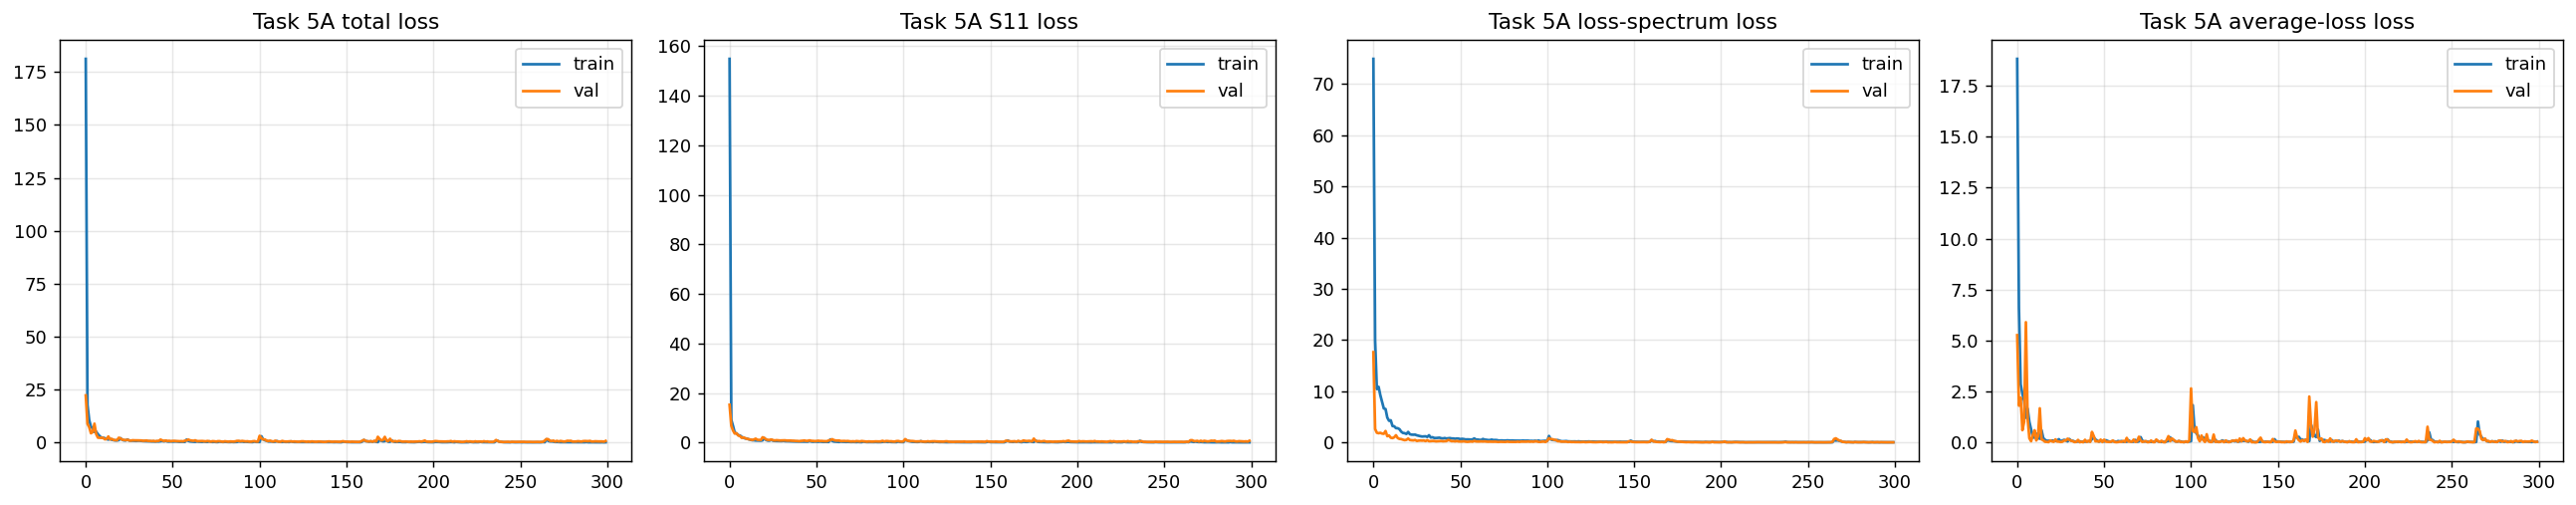

In [95]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].plot(history5["train_total"], label="train")
axes[0].plot(history5["val_total"], label="val")
axes[0].set_title("Task 5A total loss")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history5["train_s11"], label="train")
axes[1].plot(history5["val_s11"], label="val")
axes[1].set_title("Task 5A S11 loss")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(history5["train_lossspec"], label="train")
axes[2].plot(history5["val_lossspec"], label="val")
axes[2].set_title("Task 5A loss-spectrum loss")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

axes[3].plot(history5["train_avgloss"], label="train")
axes[3].plot(history5["val_avgloss"], label="val")
axes[3].set_title("Task 5A average-loss loss")
axes[3].grid(True, alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.show()

**Evaluate Task 5A**

Task 5A S11 overall MAE: 0.01602005
Task 5A loss-spectrum overall MAE: 0.0040171696
Task 5A average-loss MAE: 0.0018431282


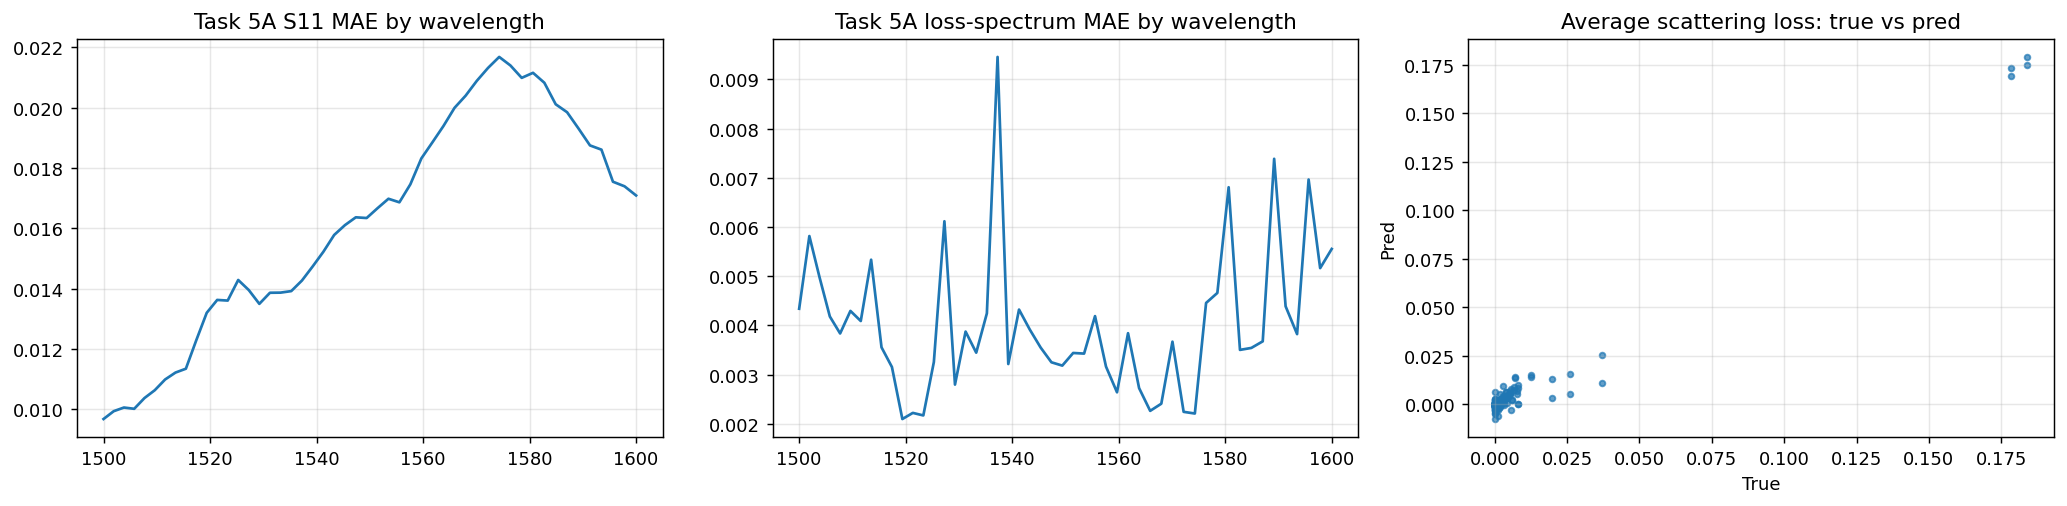

In [96]:
def collect_task5(model, loader):
    model.eval()
    p_s11_all, t_s11_all = [], []
    p_loss_all, t_loss_all, mask_all = [], [], []
    p_avg_all, t_avg_all = [], []

    with torch.no_grad():
        for x_img, x_n, y_s11, y_loss, y_mask, y_avg_loss, w in loader:
            p_s11, p_loss, p_avg = model(x_img.to(DEVICE), x_n.to(DEVICE))
            p_s11_all.append(p_s11.cpu().numpy())
            t_s11_all.append(y_s11.numpy())
            p_loss_all.append(p_loss.cpu().numpy())
            t_loss_all.append(y_loss.numpy())
            mask_all.append(y_mask.numpy())
            p_avg_all.append(p_avg.cpu().numpy())
            t_avg_all.append(y_avg_loss.numpy())

    return (
        np.concatenate(p_s11_all, axis=0),
        np.concatenate(t_s11_all, axis=0),
        np.concatenate(p_loss_all, axis=0),
        np.concatenate(t_loss_all, axis=0),
        np.concatenate(mask_all, axis=0),
        np.concatenate(p_avg_all, axis=0),
        np.concatenate(t_avg_all, axis=0),
    )

p_s11, t_s11, p_loss, t_loss, loss_mask, p_avg, t_avg = collect_task5(task5_model, task5_test_dl)

mae_s11 = np.mean(np.abs(p_s11 - t_s11), axis=0)
abs_loss_err = np.abs(p_loss - t_loss) * loss_mask
mae_loss = abs_loss_err.sum(axis=0) / np.clip(loss_mask.sum(axis=0), 1, None)
mae_avg = np.mean(np.abs(p_avg - t_avg))

print("Task 5A S11 overall MAE:", mae_s11.mean())
print("Task 5A loss-spectrum overall MAE:", np.nanmean(mae_loss))
print("Task 5A average-loss MAE:", mae_avg)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(wavelengths_nm, mae_s11)
axes[0].set_title("Task 5A S11 MAE by wavelength")
axes[0].grid(True, alpha=0.3)

axes[1].plot(wavelengths_nm, mae_loss)
axes[1].set_title("Task 5A loss-spectrum MAE by wavelength")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(t_avg.flatten(), p_avg.flatten(), s=10, alpha=0.7)
axes[2].set_title("Average scattering loss: true vs pred")
axes[2].set_xlabel("True")
axes[2].set_ylabel("Pred")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Plot a few Task 5A test examples**

Number of test examples with at least one valid loss point: 148


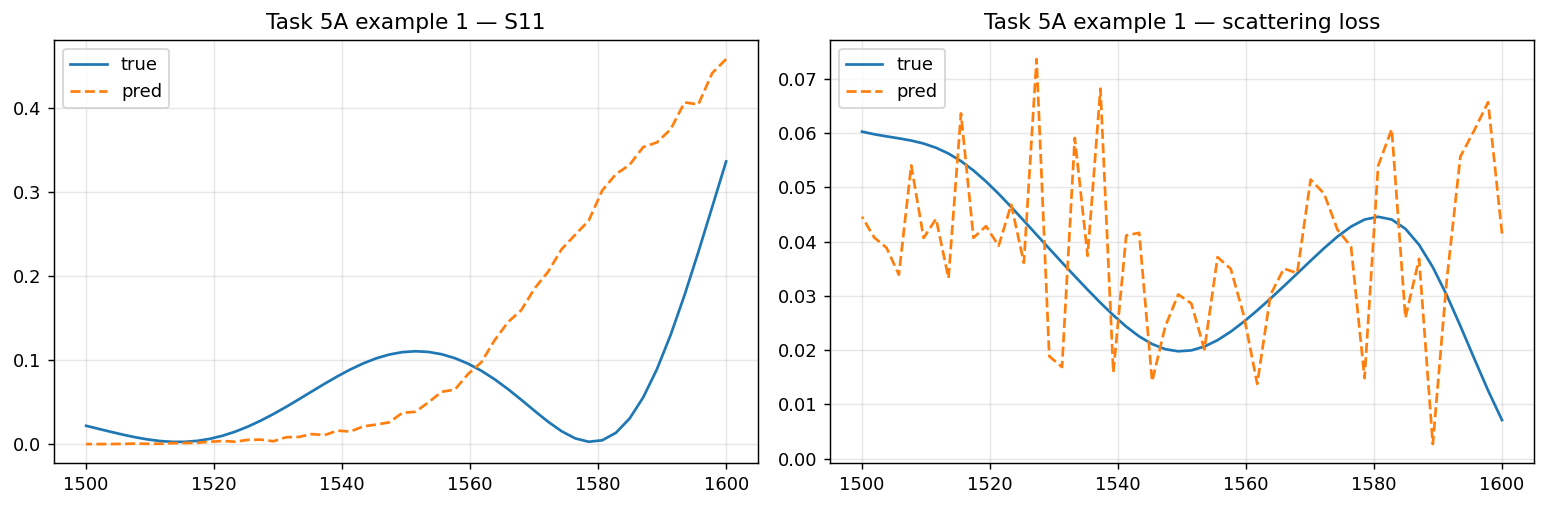

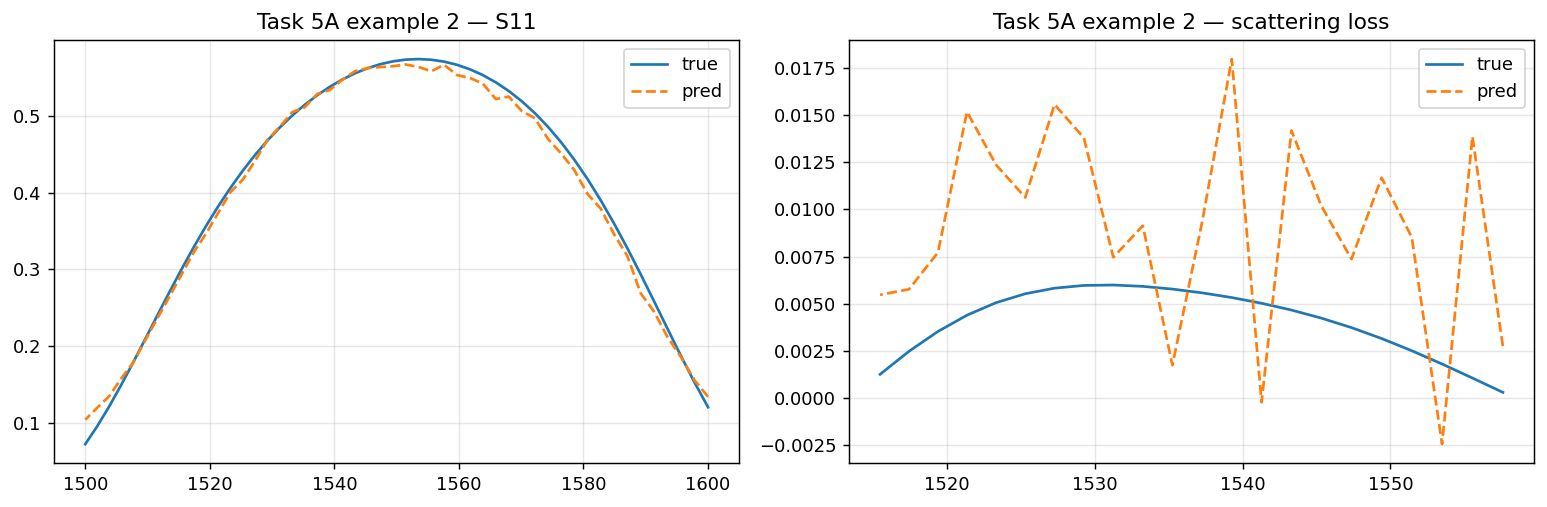

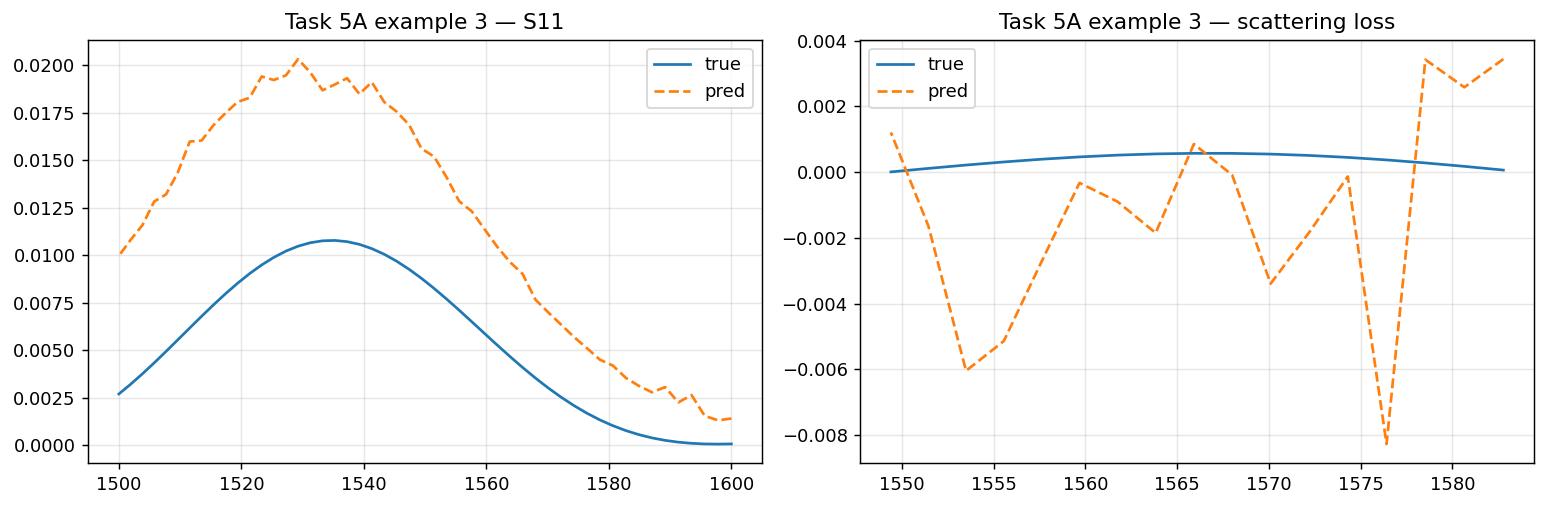

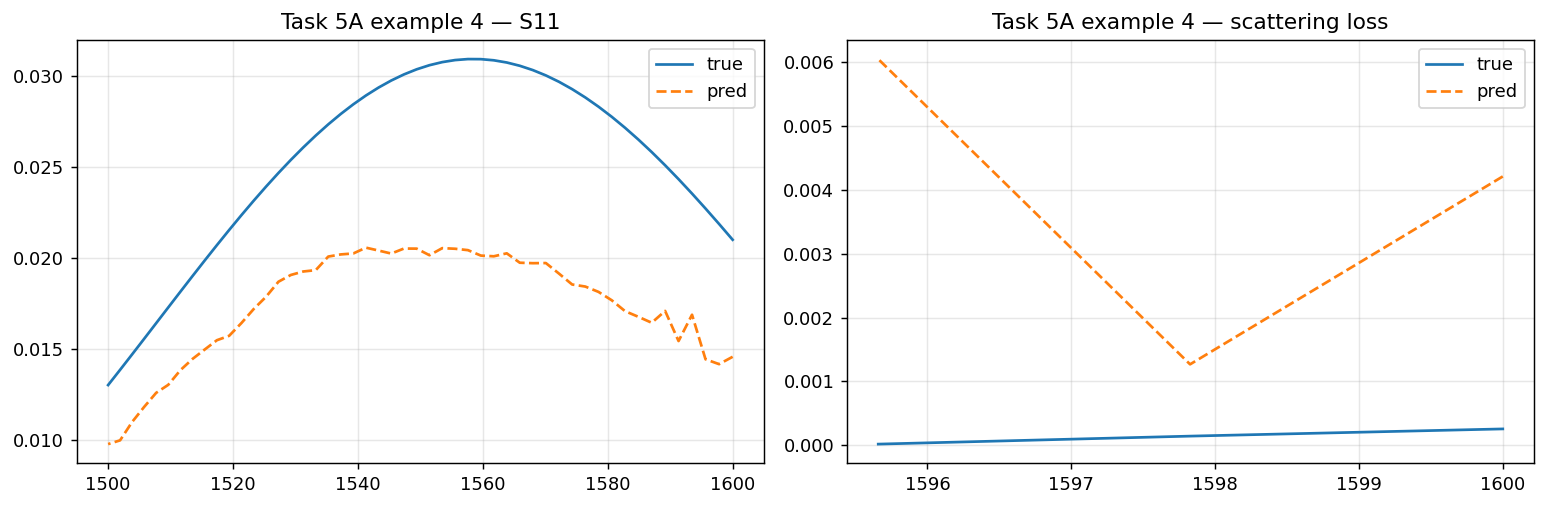

In [97]:
valid_example_indices = [i for i in range(len(p_s11)) if (loss_mask[i] > 0).sum() > 0]

print("Number of test examples with at least one valid loss point:", len(valid_example_indices))

idxs = np.random.choice(valid_example_indices, size=min(4, len(valid_example_indices)), replace=False)

for k, i in enumerate(idxs, start=1):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(wavelengths_nm, t_s11[i], label="true")
    axes[0].plot(wavelengths_nm, p_s11[i], label="pred", linestyle="--")
    axes[0].set_title(f"Task 5A example {k} — S11")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    valid = loss_mask[i] > 0
    if valid.sum() > 0:
        axes[1].plot(wavelengths_nm[valid], t_loss[i][valid], label="true")
        axes[1].plot(wavelengths_nm[valid], p_loss[i][valid], label="pred", linestyle="--")
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, "No valid loss labels for this sample",
                     ha="center", va="center", transform=axes[1].transAxes)

    axes[1].set_title(f"Task 5A example {k} — scattering loss")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

After reducing the loss-spectrum weight to `beta = 0.1`, the model places much more emphasis on learning the `S11` spectrum and the average loss target, while treating the full `scattering_loss_per_period_dB` spectrum as a weaker auxiliary objective. This makes sense because the loss spectrum is visibly harder to learn: in the examples above, the `S11` predictions are often much closer to the true curve shape, especially for smoother cases, whereas the loss-spectrum predictions are still noisy, jagged, and sometimes physically unrealistic. In other words, lowering `beta` helps prevent the difficult loss-spectrum task from dominating training and damaging the more important `S11` prediction. The results suggest that this tradeoff is reasonable: the model learns `S11` better, but the full wavelength-by-wavelength loss spectrum remains challenging and should be interpreted as a secondary target rather than the main success criterion.

Task 4B is an inverse-design problem where the input is a target spectrum, namely `S11(50)` and `S12(50)`, and the output is the geometry image `index_images (40,20)` together with a recommended period number `n`. The main difficulty is that this mapping is generally **not unique**: multiple different geometries can produce very similar spectra, so the inverse problem is one-to-many rather than one-to-one. Because of that, the most practical strategy is to first build a **deterministic baseline** inverse model, then verify its predicted geometries using the already trained **forward model**, and finally present more advanced stochastic methods such as a **conditional VAE** or **conditional GAN** as future improvements. This gives a clear and defensible project story: first show that inverse mapping is possible at all, then check physical consistency with the forward predictor, and only after that move to more sophisticated generative models.

**Build Task 4B inverse dataset**

In [100]:
task4b_rows = []
for s in task4_samples:
    cond = np.concatenate([s["s11"], s["s12"]]).astype(np.float32)   # (100,)
    img  = s["image"].astype(np.float32)                             # (40,20)
    n_t  = np.array([(s["n"] - 10.0) / 10.0], dtype=np.float32)      # scalar in {0,1}

    task4b_rows.append({
        "design_key": s["design_key"],
        "cond": cond,
        "image": img,
        "n_target": n_t
    })

task4b_train, task4b_val, task4b_test = split_samples(task4b_rows)
print(len(task4b_train), len(task4b_val), len(task4b_test))

930 200 200


**Dataset and model for Task 4B**

In [124]:
all_imgs = np.stack([normalize_image(d["index_images"]) for d in designs], axis=0)
mean_img = all_imgs.mean(axis=0)

core_mask = mean_img > 0.90

core_mask_t = torch.tensor(core_mask[None, None].astype(np.float32))
dilate = F.max_pool2d(core_mask_t, kernel_size=3, stride=1, padding=1)
erode = -F.max_pool2d(-core_mask_t, kernel_size=3, stride=1, padding=1)
edge_mask = ((dilate - erode) > 0).cpu().numpy()[0, 0]

edge_values = all_imgs[:, edge_mask]
EDGE_MIN = float(np.min(edge_values))
EDGE_MAX = float(np.max(edge_values))
CORE_VALUE = float(np.median(all_imgs[:, core_mask]))

print("CORE_VALUE =", CORE_VALUE)
print("EDGE_MIN, EDGE_MAX =", EDGE_MIN, EDGE_MAX)

class Task4BInverseDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows[idx]
        cond = torch.tensor(r["cond"], dtype=torch.float32)
        img  = torch.tensor(r["image"][None, :, :], dtype=torch.float32)
        n_t  = torch.tensor(r["n_target"], dtype=torch.float32)
        return cond, img, n_t


class Task4BInverseMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(100, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.img_head = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 40 * 20),
            nn.Sigmoid(),
        )
        self.n_head = nn.Sequential(
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, cond):
        z = self.enc(cond)
        img = self.img_head(z).view(-1, 1, 40, 20)
        n_hat = self.n_head(z)
        return img, n_hat


task4b_train_dl = DataLoader(Task4BInverseDataset(task4b_train), batch_size=32, shuffle=True)
task4b_val_dl   = DataLoader(Task4BInverseDataset(task4b_val),   batch_size=32, shuffle=False)
task4b_test_dl  = DataLoader(Task4BInverseDataset(task4b_test),  batch_size=32, shuffle=False)

CORE_VALUE = 0.9999999403953552
EDGE_MIN, EDGE_MAX = 0.0 0.9999999403953552


**Train Task 4B inverse baseline**

In [125]:
def run_epoch_task4b(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    total = 0.0
    total_n = 0

    for cond, img, n_t in loader:
        cond = cond.to(DEVICE)
        img  = img.to(DEVICE)
        n_t  = n_t.to(DEVICE)

        p_img, p_n = model(cond)

        loss_img = F.mse_loss(p_img, img)
        loss_n   = F.mse_loss(p_n, n_t)
        loss = loss_img + 0.2 * loss_n

        if train_mode:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        bs = cond.size(0)
        total += loss.item() * bs
        total_n += bs

    return total / total_n


inv4_model = Task4BInverseMLP().to(DEVICE)
opt_inv4 = torch.optim.Adam(inv4_model.parameters(), lr=1e-3, weight_decay=1e-5)

hist_inv4 = {"train": [], "val": []}
best_val_inv4 = np.inf
best_state_inv4 = None

for epoch in range(500):
    tr = run_epoch_task4b(inv4_model, task4b_train_dl, optimizer=opt_inv4)
    va = run_epoch_task4b(inv4_model, task4b_val_dl, optimizer=None)

    hist_inv4["train"].append(tr)
    hist_inv4["val"].append(va)

    if va < best_val_inv4:
        best_val_inv4 = va
        best_state_inv4 = {k: v.cpu().clone() for k, v in inv4_model.state_dict().items()}

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d} | train={tr:.6f} | val={va:.6f}")

inv4_model.load_state_dict(best_state_inv4)
print("Best val:", best_val_inv4)

Epoch 001 | train=0.204623 | val=0.151668
Epoch 010 | train=0.133392 | val=0.157028
Epoch 020 | train=0.116556 | val=0.115461
Epoch 030 | train=0.106736 | val=0.101245
Epoch 040 | train=0.103029 | val=0.099568
Epoch 050 | train=0.103319 | val=0.101627
Epoch 060 | train=0.089353 | val=0.098238
Epoch 070 | train=0.090270 | val=0.088491
Epoch 080 | train=0.099921 | val=0.105846
Epoch 090 | train=0.094770 | val=0.090617
Epoch 100 | train=0.079936 | val=0.092975
Epoch 110 | train=0.082264 | val=0.103719
Epoch 120 | train=0.079515 | val=0.093114
Epoch 130 | train=0.076723 | val=0.099852
Epoch 140 | train=0.091802 | val=0.088775
Epoch 150 | train=0.082953 | val=0.081432
Epoch 160 | train=0.077483 | val=0.078597
Epoch 170 | train=0.077760 | val=0.077805
Epoch 180 | train=0.073236 | val=0.084306
Epoch 190 | train=0.077513 | val=0.079982
Epoch 200 | train=0.081303 | val=0.089752
Epoch 210 | train=0.067001 | val=0.083248
Epoch 220 | train=0.068065 | val=0.073448
Epoch 230 | train=0.074646 | val=0

**Plot Task 4B learning curve**

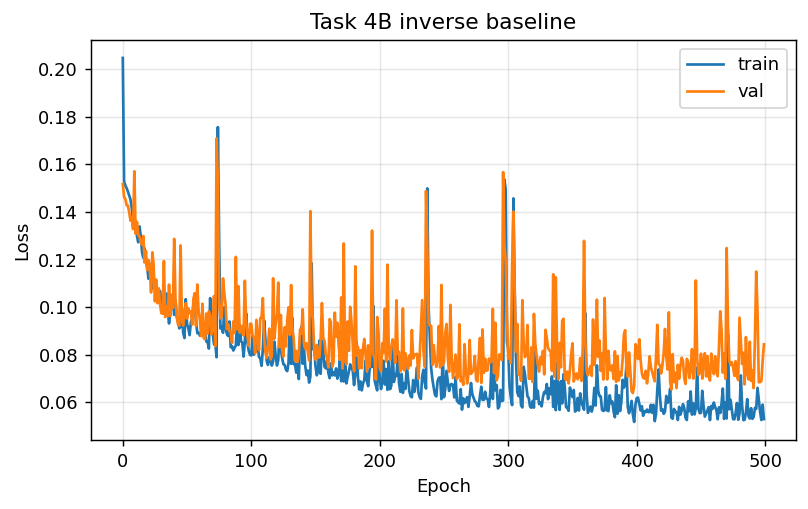

In [126]:
plt.figure(figsize=(7,4))
plt.plot(hist_inv4["train"], label="train")
plt.plot(hist_inv4["val"], label="val")
plt.title("Task 4B inverse baseline")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Show generated Task 4B images**

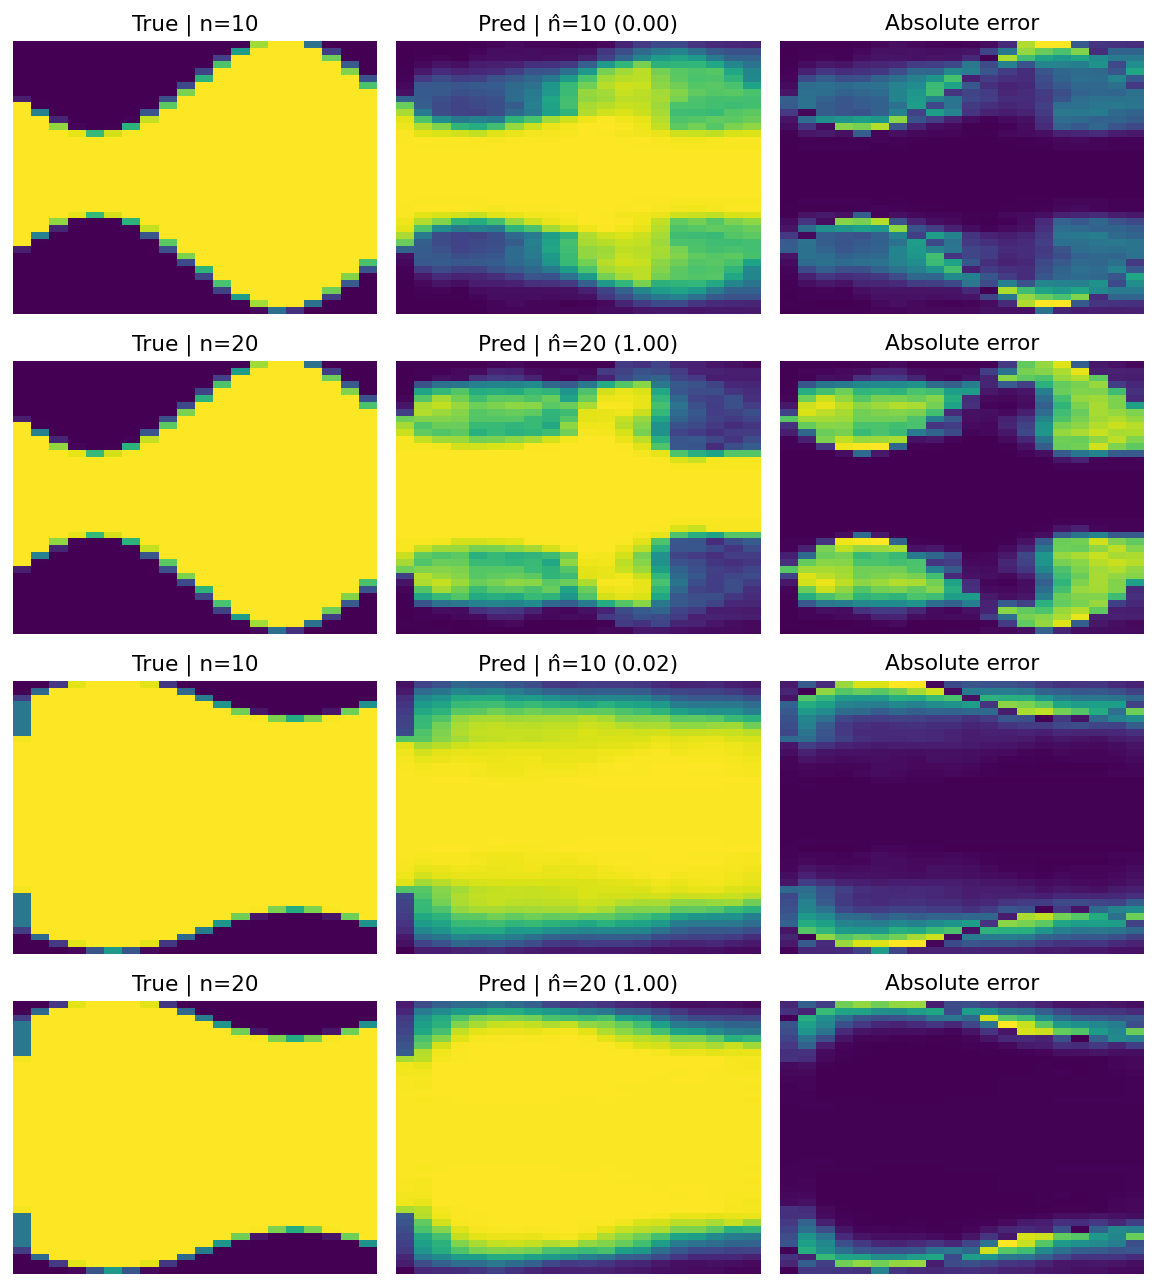

In [127]:
batch = next(iter(task4b_test_dl))
cond, img_true, n_true = batch

inv4_model.eval()
with torch.no_grad():
    img_pred, n_pred = inv4_model(cond.to(DEVICE))

img_pred = img_pred.cpu().numpy()
n_pred   = n_pred.cpu().numpy()
img_true = img_true.numpy()
n_true   = n_true.numpy()

fig, axes = plt.subplots(4, 3, figsize=(9, 10))
for i in range(4):
    axes[i,0].imshow(img_true[i,0], origin="lower", aspect="auto")
    axes[i,0].set_title(f"True | n={10 if n_true[i,0] < 0.5 else 20}")
    axes[i,0].axis("off")

    axes[i,1].imshow(img_pred[i,0], origin="lower", aspect="auto")
    axes[i,1].set_title(f"Pred | n̂={10 if n_pred[i,0] < 0.5 else 20} ({n_pred[i,0]:.2f})")
    axes[i,1].axis("off")

    axes[i,2].imshow(np.abs(img_true[i,0] - img_pred[i,0]), origin="lower", aspect="auto")
    axes[i,2].set_title("Absolute error")
    axes[i,2].axis("off")

plt.tight_layout()
plt.show()

**Forward-consistency check for Task 4B**

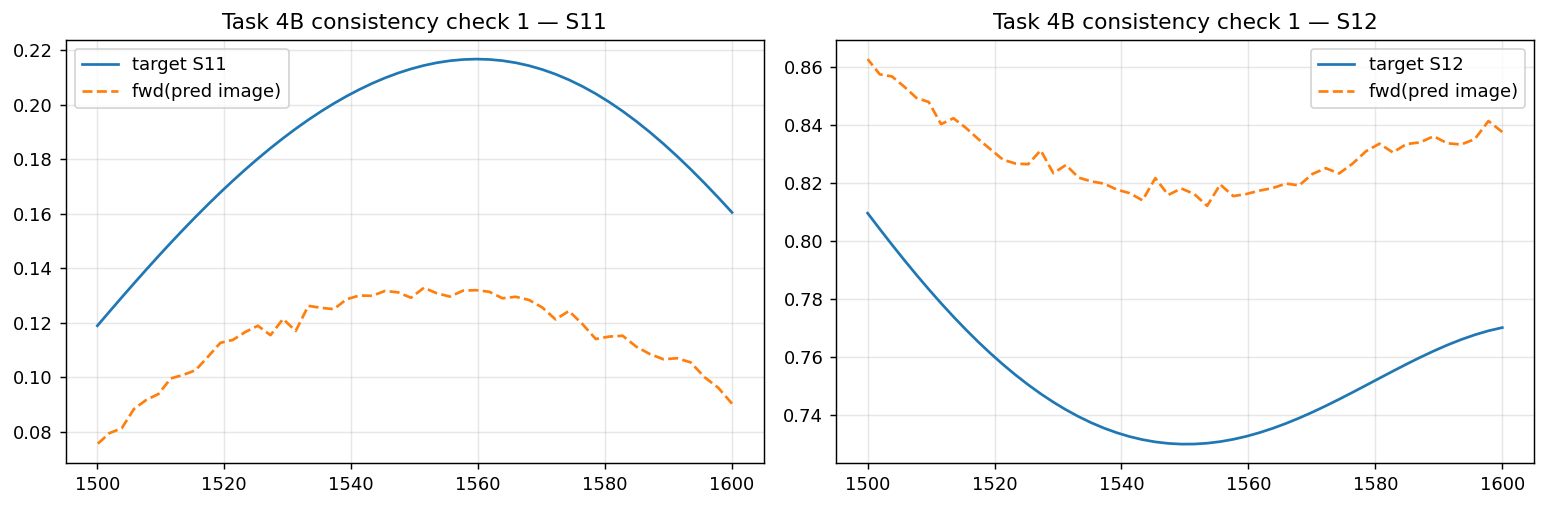

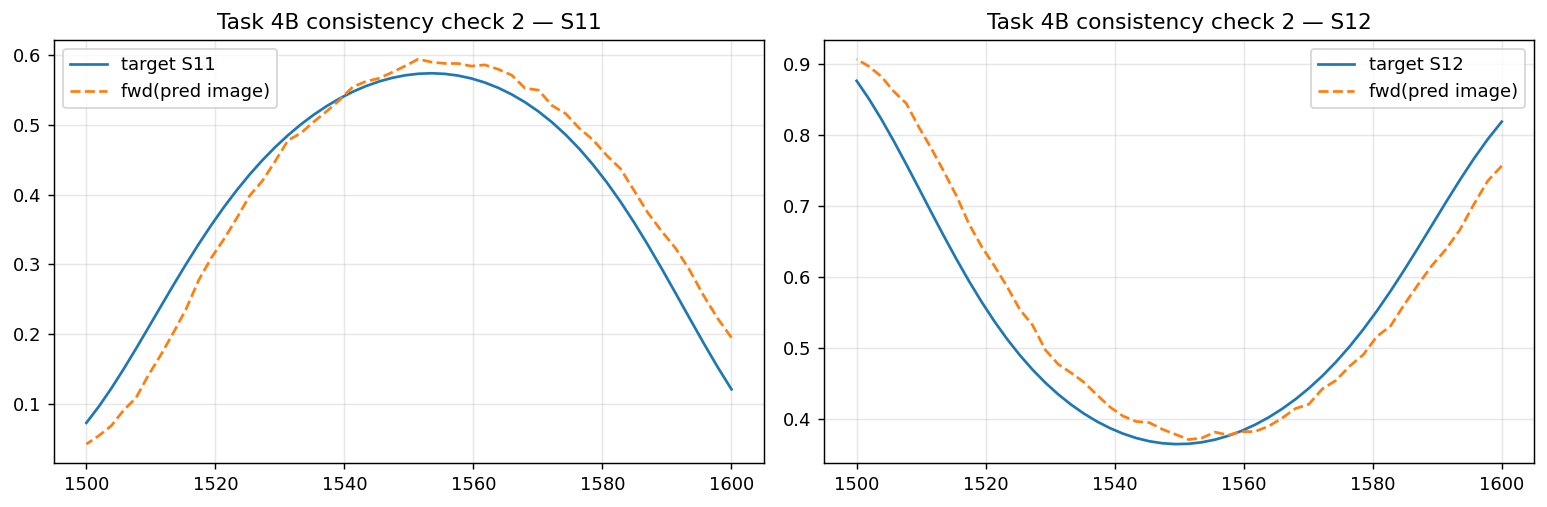

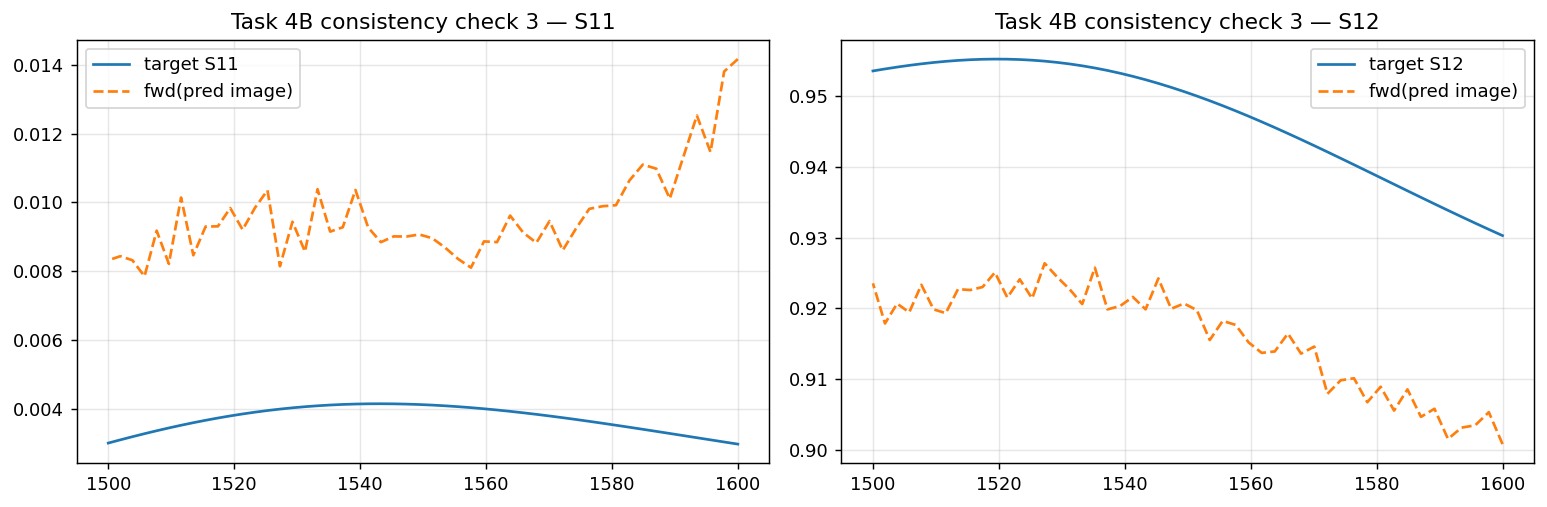

In [128]:
# We use the already-trained Task 4A forward model to check whether the generated image
# reproduces the target spectrum.

inv4_model.eval()
task4_model.eval()

batch = next(iter(task4b_test_dl))
cond, img_true, n_true = batch

with torch.no_grad():
    img_pred, n_pred = inv4_model(cond.to(DEVICE))
    spec_reconstructed = task4_model(img_pred, n_pred).cpu().numpy()

cond = cond.numpy()

for i in range(3):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(wavelengths_nm, cond[i, :50], label="target S11")
    axes[0].plot(wavelengths_nm, spec_reconstructed[i, :50], label="fwd(pred image)", linestyle="--")
    axes[0].set_title(f"Task 4B consistency check {i+1} — S11")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(wavelengths_nm, cond[i, 50:], label="target S12")
    axes[1].plot(wavelengths_nm, spec_reconstructed[i, 50:], label="fwd(pred image)", linestyle="--")
    axes[1].set_title(f"Task 4B consistency check {i+1} — S12")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

We also experimented with adding stronger fabrication-aware constraints to the generator. The idea was to reduce blur and make the predicted structures more realistic by keeping the inner core more uniform, limiting most of the learnable variation to the boundary region, and restricting generated values to a physically plausible range. In principle this is a sensible direction, but in our current experiments these added constraints made the inverse model noticeably harder to train and reduced reconstruction quality. For that reason, we did not keep those stricter generator constraints in the final version of the notebook. Instead, we keep the generator as a simpler baseline inverse model and evaluate it using forward-consistency checks. This experiment was still useful, because it helped clarify an important tradeoff: more fabrication-aware structure may improve realism, but it can also reduce learnability when the inverse problem is already difficult and non-unique. On the predictor side, however, the suggested improvements were much more successful, so we kept the physically motivated S11/S12 structure, smoothing terms, large-period stress testing, and the auxiliary average-loss target.

Task 5B is an inverse-design problem in which the input consists of only two scalar target quantities at a chosen wavelength, namely `S11(λ*)` and `loss(λ*)`, while the output is a full geometry image `index_images (40,20)` together with a recommended period number `n`. This task is especially challenging because two scalar constraints are far too little information to uniquely determine a single geometry: many different photonic crystal structures can produce similar reflectance and loss values at one wavelength. In other words, the mapping is inherently **one-to-many** rather than one-to-one. For that reason, a plain deterministic regression model is not the best choice, since it tends to average multiple possible solutions and may produce blurry or physically unrealistic geometries. A better approach is to use a **conditional variational autoencoder (cVAE)**, which models the uncertainty and design freedom of the inverse problem by learning a latent space of possible solutions. Then, for the same desired `(S11, loss)` target pair, the model can generate multiple candidate geometries instead of forcing a single averaged answer. This makes the method much more suitable for inverse photonic design, where diversity of valid solutions is actually an advantage rather than a problem.

**Pick the wavelength for Task 5B**

In [129]:

# 1550 nm is the obvious telecom choice.

TARGET_WL = 1550.0
target_idx = int(np.argmin(np.abs(wavelengths_nm - TARGET_WL)))

print("Chosen wavelength index:", target_idx)
print("Actual wavelength:", wavelengths_nm[target_idx])

Chosen wavelength index: 24
Actual wavelength: 1549.4071


**Build Task 5B dataset**

In [136]:
task5b_rows = []

for s in task5_samples:
    loss_val = s["loss"][target_idx]
    if not np.isfinite(loss_val):
        continue

    cond = np.array([s["s11"][target_idx], loss_val], dtype=np.float32)

    task5b_rows.append({
        "design_key": s["design_key"],
        "cond": cond,                                           # [S11@lambda*, loss@lambda*]
        "image": s["image"].astype(np.float32),                 # (40,20)
        "n_target": np.array([(s["n"] - 10.0)/10.0], dtype=np.float32)
    })

task5b_train, task5b_val, task5b_test = split_samples(task5b_rows)
print("Task 5B samples:", len(task5b_rows))
print("Split:", len(task5b_train), len(task5b_val), len(task5b_test))

Task 5B samples: 638
Split: 458 84 96


**Dataset and conditional VAE**

In [137]:
class Task5BDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        r = self.rows[idx]
        cond = torch.tensor(r["cond"], dtype=torch.float32)                     # (2,)
        img_flat = torch.tensor(r["image"].reshape(-1), dtype=torch.float32)   # (800,)
        n_t = torch.tensor(r["n_target"], dtype=torch.float32)                  # (1,)
        x = torch.cat([img_flat, n_t], dim=0)                                   # (801,)
        return cond, x


class ConditionalVAE(nn.Module):
    def __init__(self, cond_dim=2, x_dim=801, z_dim=16):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(x_dim + cond_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.mu = nn.Linear(128, z_dim)
        self.logvar = nn.Linear(128, z_dim)

        self.dec = nn.Sequential(
            nn.Linear(z_dim + cond_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, x_dim)
        )

    def encode(self, x, c):
        h = self.enc(torch.cat([x, c], dim=1))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        out = self.dec(torch.cat([z, c], dim=1))
        img = torch.sigmoid(out[:, :800]).view(-1, 1, 40, 20)
        n_hat = torch.sigmoid(out[:, 800:801])
        return img, n_hat

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        img, n_hat = self.decode(z, c)
        return img, n_hat, mu, logvar


def cvae_loss(img_pred, n_pred, x_true, mu, logvar, beta=1e-3):
    img_true = x_true[:, :800].view(-1, 1, 40, 20)
    n_true   = x_true[:, 800:801]

    recon_img = F.mse_loss(img_pred, img_true)
    recon_n   = F.mse_loss(n_pred, n_true)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    return recon_img + 0.2 * recon_n + beta * kl, recon_img.item(), recon_n.item(), kl.item()


task5b_train_dl = DataLoader(Task5BDataset(task5b_train), batch_size=32, shuffle=True)
task5b_val_dl   = DataLoader(Task5BDataset(task5b_val),   batch_size=32, shuffle=False)
task5b_test_dl  = DataLoader(Task5BDataset(task5b_test),  batch_size=32, shuffle=False)

**Train the Task 5B cVAE**

In [139]:
cvae = ConditionalVAE().to(DEVICE)
opt_cvae = torch.optim.Adam(cvae.parameters(), lr=1e-4, weight_decay=1e-5)

hist_cvae = {"train": [], "val": []}
best_val_cvae = np.inf
best_state_cvae = None

for epoch in range(500):
    cvae.train()
    tr_total = 0.0
    tr_n = 0

    for cond, x in task5b_train_dl:
        cond = cond.to(DEVICE)
        x = x.to(DEVICE)

        img_pred, n_pred, mu, logvar = cvae(x, cond)
        loss, _, _, _ = cvae_loss(img_pred, n_pred, x, mu, logvar, beta=1e-3)

        opt_cvae.zero_grad()
        loss.backward()
        opt_cvae.step()

        bs = cond.size(0)
        tr_total += loss.item() * bs
        tr_n += bs

    cvae.eval()
    va_total = 0.0
    va_n = 0

    with torch.no_grad():
        for cond, x in task5b_val_dl:
            cond = cond.to(DEVICE)
            x = x.to(DEVICE)

            img_pred, n_pred, mu, logvar = cvae(x, cond)
            loss, _, _, _ = cvae_loss(img_pred, n_pred, x, mu, logvar, beta=1e-3)

            bs = cond.size(0)
            va_total += loss.item() * bs
            va_n += bs

    tr = tr_total / tr_n
    va = va_total / va_n

    hist_cvae["train"].append(tr)
    hist_cvae["val"].append(va)

    if va < best_val_cvae:
        best_val_cvae = va
        best_state_cvae = {k: v.cpu().clone() for k, v in cvae.state_dict().items()}

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d} | train={tr:.6f} | val={va:.6f}")

cvae.load_state_dict(best_state_cvae)
print("Best val:", best_val_cvae)

Epoch 001 | train=0.283464 | val=0.279822
Epoch 010 | train=0.144290 | val=0.146961
Epoch 020 | train=0.137840 | val=0.139976
Epoch 030 | train=0.116034 | val=0.110670
Epoch 040 | train=0.106079 | val=0.101643
Epoch 050 | train=0.090258 | val=0.088656
Epoch 060 | train=0.083786 | val=0.084070
Epoch 070 | train=0.079360 | val=0.079935
Epoch 080 | train=0.065826 | val=0.066411
Epoch 090 | train=0.039567 | val=0.040779
Epoch 100 | train=0.032956 | val=0.034694
Epoch 110 | train=0.030886 | val=0.032786
Epoch 120 | train=0.029688 | val=0.031588
Epoch 130 | train=0.028877 | val=0.031103
Epoch 140 | train=0.027794 | val=0.030349
Epoch 150 | train=0.026900 | val=0.030058
Epoch 160 | train=0.025880 | val=0.029048
Epoch 170 | train=0.024778 | val=0.028395
Epoch 180 | train=0.023949 | val=0.027535
Epoch 190 | train=0.023187 | val=0.026930
Epoch 200 | train=0.022665 | val=0.026557
Epoch 210 | train=0.022049 | val=0.026060
Epoch 220 | train=0.021690 | val=0.025811
Epoch 230 | train=0.021308 | val=0

**Plot Task 5B learning curve**

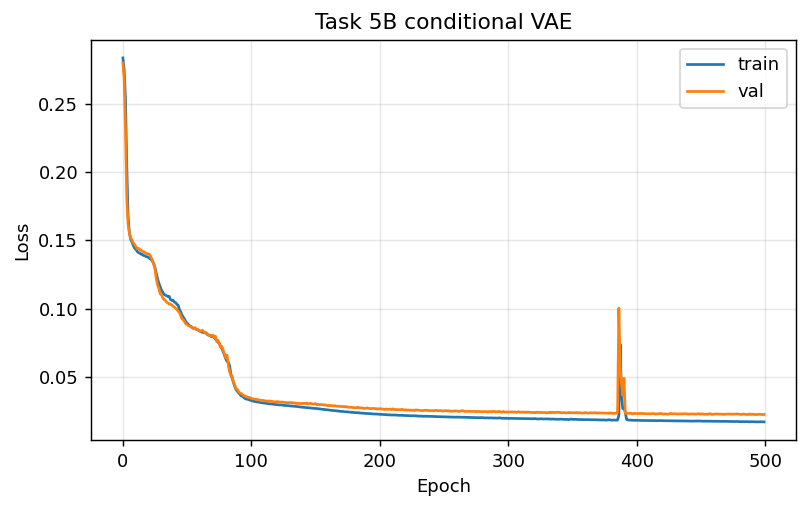

In [140]:
plt.figure(figsize=(7,4))
plt.plot(hist_cvae["train"], label="train")
plt.plot(hist_cvae["val"], label="val")
plt.title("Task 5B conditional VAE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

**Sample multiple candidate designs for the same target**

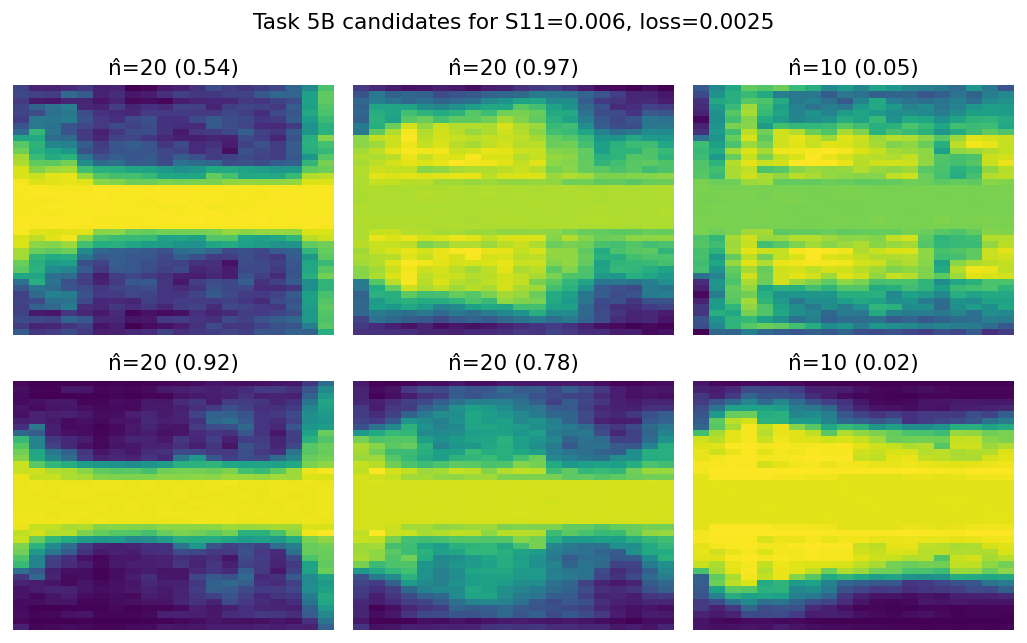

In [141]:
def sample_task5b(model, target_s11, target_loss, n_samples=6, z_dim=16):
    model.eval()
    c = torch.tensor([[target_s11, target_loss]], dtype=torch.float32, device=DEVICE).repeat(n_samples, 1)
    z = torch.randn(n_samples, z_dim, device=DEVICE)
    with torch.no_grad():
        imgs, n_hat = model.decode(z, c)
    return imgs.cpu().numpy(), n_hat.cpu().numpy()

all_cond = np.array([r["cond"] for r in task5b_rows], dtype=np.float32)
target_s11 = float(np.median(all_cond[:, 0]))
target_loss = float(np.median(all_cond[:, 1]))

cand_imgs, cand_n = sample_task5b(cvae, target_s11, target_loss, n_samples=6)

fig, axes = plt.subplots(2, 3, figsize=(8, 5))
for ax, img, n_hat in zip(axes.ravel(), cand_imgs, cand_n):
    ax.imshow(img[0], origin="lower", aspect="auto")
    ax.set_title(f"n̂={10 if n_hat[0] < 0.5 else 20} ({n_hat[0]:.2f})")
    ax.axis("off")

plt.suptitle(f"Task 5B candidates for S11={target_s11:.3f}, loss={target_loss:.4f}")
plt.tight_layout()
plt.show()

**verify Task 5B candidates with the forward models**

candidate 0: pred S11@1549.41nm = 0.0024, pred loss@1549.41nm = 0.0165, pred avg_loss = 0.0214


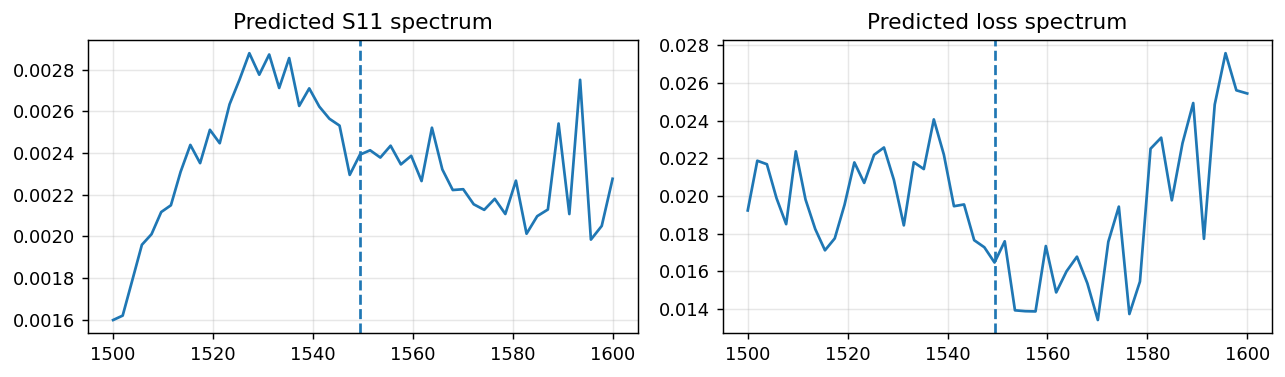

candidate 1: pred S11@1549.41nm = 0.0236, pred loss@1549.41nm = 0.0030, pred avg_loss = 0.0028


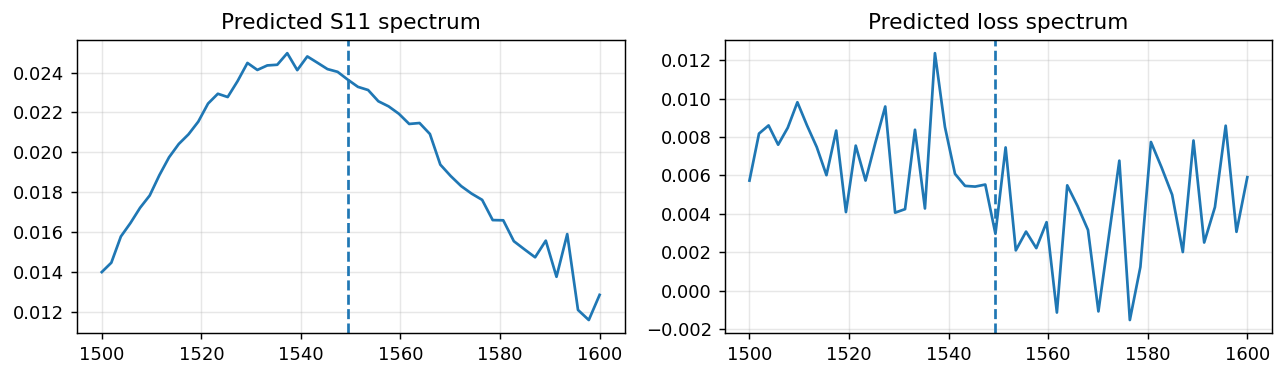

candidate 2: pred S11@1549.41nm = 0.0025, pred loss@1549.41nm = 0.0080, pred avg_loss = 0.0075


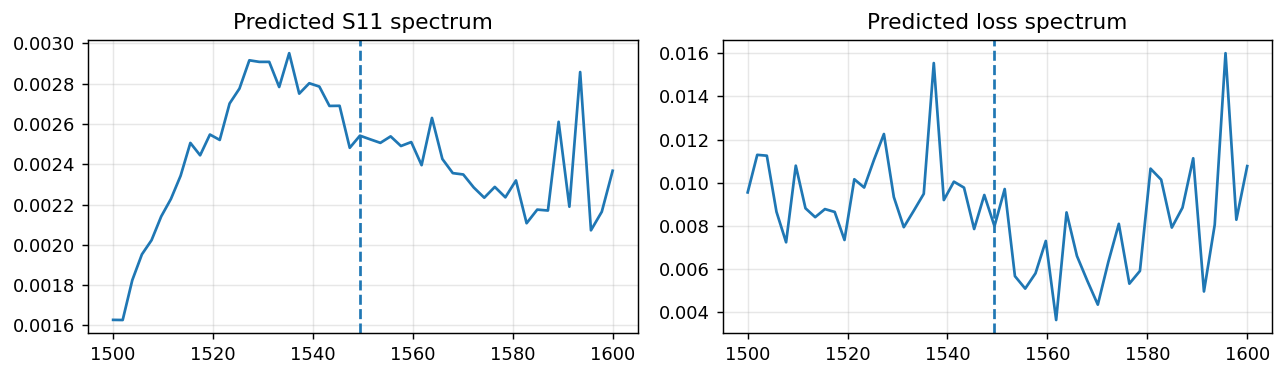

candidate 3: pred S11@1549.41nm = 0.0080, pred loss@1549.41nm = 0.0241, pred avg_loss = 0.0251


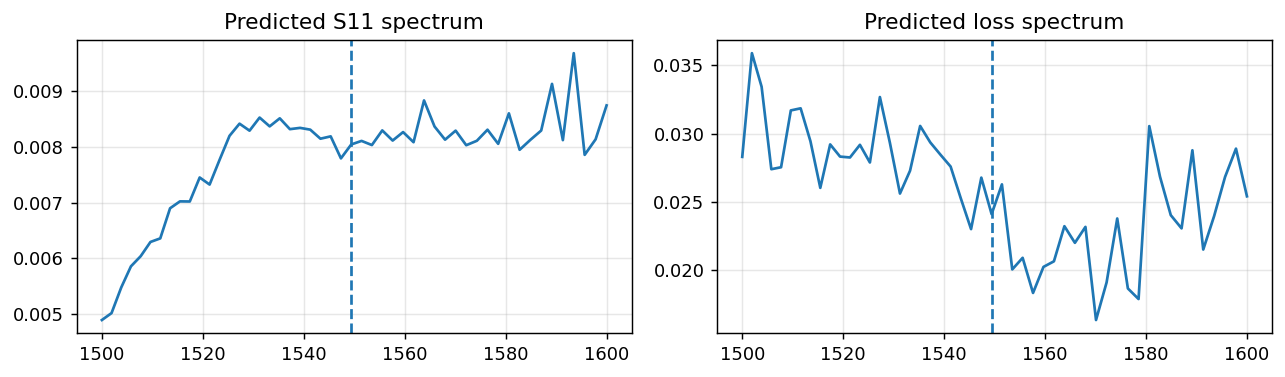

In [144]:
# For generated (image, n), run the Task 5A forward model
# and inspect S11 / loss at the selected wavelength.

target_s11 = float(np.median(all_cond[:, 0]))
target_loss = float(np.median(all_cond[:, 1]))

cand_imgs, cand_n = sample_task5b(cvae, target_s11, target_loss, n_samples=4)

cand_imgs_t = torch.tensor(cand_imgs, dtype=torch.float32).to(DEVICE)
cand_n_t = torch.tensor(cand_n, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    pred_s11_spec, pred_loss_spec, pred_avg_loss = task5_model(cand_imgs_t, cand_n_t)

pred_s11_spec = pred_s11_spec.cpu().numpy()
pred_loss_spec = pred_loss_spec.cpu().numpy()
pred_avg_loss = pred_avg_loss.cpu().numpy()

for i in range(4):
    print(
        f"candidate {i}: "
        f"pred S11@{wavelengths_nm[target_idx]:.2f}nm = {pred_s11_spec[i, target_idx]:.4f}, "
        f"pred loss@{wavelengths_nm[target_idx]:.2f}nm = {pred_loss_spec[i, target_idx]:.4f}, "
        f"pred avg_loss = {pred_avg_loss[i, 0]:.4f}"
    )

    plt.figure(figsize=(10,3))

    plt.subplot(1,2,1)
    plt.plot(wavelengths_nm, pred_s11_spec[i])
    plt.axvline(wavelengths_nm[target_idx], linestyle="--")
    plt.title("Predicted S11 spectrum")
    plt.grid(True, alpha=0.3)

    plt.subplot(1,2,2)
    plt.plot(wavelengths_nm, pred_loss_spec[i])
    plt.axvline(wavelengths_nm[target_idx], linestyle="--")
    plt.title("Predicted loss spectrum")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()